<a href="https://colab.research.google.com/github/hd77alu/gbv-tweet-classification-nlp/blob/main/notebook/gbv_tweet_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gender-Based Violence (GBV) Tweet Classification

## Introduction

Gender-Based Violence (GBV) remains a critical human rights violation and public health issue across African communities and globally[cite: 1, 2]. Social media platforms—particularly X (formerly Twitter)—have become primary digital spaces where individuals report incidents, seek help, or share experiences[cite: 1, 2]. However, the sheer volume, informal nature, and noisy character of social media text make manual monitoring inefficient.

The objective of this project is to develop machine learning and deep learning models to automatically classify online tweets into five distinct categories of violence[cite: 2]:
1. **Sexual Violence**
2. **Physical Violence**
3. **Emotional Violence**
4. **Economic Violence**
5. **Harmful Traditional Practices**


### Core Research Question

> How effectively can sequential modelling approaches be used to address a real-world NLP or language technology problem, and what evidence supports the strengths and limitations of the selected approaches?

### Importing Necessary Libaries

In [ ]:
%pip install -q transformers emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 17.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path
import os
from shutil import copy2
from google.colab import drive
import copy
import random
import warnings
import json
import datetime as dt
import time

import html
import urllib.request
import zipfile
import re
import joblib
import unicodedata

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          DataCollatorWithPadding, get_linear_schedule_with_warmup)

import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
train_df = pd.read_csv('/content/Train.csv')
test_df = pd.read_csv('/content/Test.csv')

## Problem & data investigation

In [ ]:
train_df.head(10)

,Tweet_ID,tweet,type
0,ID_0022DWKP,Had a dream i got raped last night. By a guy i...,sexual_violence
1,ID_00395QYM,he thought the word raped means sex and told m...,sexual_violence
2,ID_003EOSSF,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,ID_004BBHOD,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,ID_004F7516,Chessy Prout can do better by telling the trut...,sexual_violence
5,ID_0052TYKI,"Yes men rape women. But women also rape men, y...",sexual_violence
6,ID_0058QG76,"My Husband Beats Me Frequently, Wife Tells Cou...",Physical_violence
7,ID_005VM1DJ,Pretty sure he raped a 16yr old girl with 2 fr...,sexual_violence
8,ID_0060BW8R,TW sorry to hear that and yeah he recently th...,sexual_violence
9,ID_007FAIEI,"""I understand that... My father was abusive as...",sexual_violence


In [ ]:
test_df.head()

,Tweet_ID,tweet
0,ID_0095QL4S,"because he was my boyfriend, and if I said no,..."
1,ID_00DREW5O,"lol no, I'm telling you it's not legal. It's l..."
2,ID_00E9F5X9,Somalia's semi-autonomous Puntland region has ...
3,ID_00G9OSKZ,University of Cape Coast students being robbed...
4,ID_00HU96U6,"""Somebody came up behind him and stabbed him i..."


In [ ]:
train_df.describe()

,Tweet_ID,tweet,type
count,39650,39650,39650
unique,39650,39642,5
top,ID_ZZZ8QEKT,my run up today: - havent eaten in 30 hours -...,sexual_violence
freq,1,3,32648


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39650 entries, 0 to 39649
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Tweet_ID  39650 non-null  object
 1   tweet     39650 non-null  object
 2   type      39650 non-null  object
dtypes: object(3)
memory usage: 929.4+ KB


In [ ]:
train_df['type'].unique()

array(['sexual_violence', 'Physical_violence', 'emotional_violence',
       'Harmful_Traditional_practice', 'economic_violence'], dtype=object)

In [ ]:
train_df['type'].value_counts()

,count
type,
sexual_violence,32648
Physical_violence,5946
emotional_violence,651
economic_violence,217
Harmful_Traditional_practice,188


In [ ]:
# Returns the total number of duplicate rows
train_df[train_df['tweet'].duplicated()]


,Tweet_ID,tweet,type
11374,ID_ABHE48A4,my run up today: - havent eaten in 30 hours -...,emotional_violence
26107,ID_NTI32D5F,"My homie invited me over to smoke, then he sta...",sexual_violence
28050,ID_PKQ5LRN1,I was insulted and humiliated in public by one...,emotional_violence
30236,ID_RIVSXQSR,my run up today: - havent eaten in 30 hours -...,emotional_violence
30504,ID_RS9ZNVRX,account is temporarily unavailable because it ...,Physical_violence
30726,ID_RZRGED0E,"and he forced me hug to him, and later he piss...",sexual_violence
37104,ID_XSCUCJBD,"This is my story. July 24, 2017 I was raped. ...",sexual_violence
37666,ID_YAV6NN9N,"I was referring to stuff like rape, DV, prosti...",Harmful_Traditional_practice


In [ ]:
def plot_distribution(df, metric_col, title_prefix):
    categories = ['Overall'] + list(df['type'].unique())
    fig, axes = plt.subplots(len(categories), 1, figsize=(10, 3 * len(categories)), sharex=True)

    for i, cat in enumerate(categories):
        ax = axes[i]
        if cat == 'Overall':
            data = df[metric_col]
        else:
            data = df[df['type'] == cat][metric_col]

        # Calculate statistics
        median_val = data.median()
        p95_val = data.quantile(0.95)

        # Plot distribution
        sns.histplot(data, bins=50, ax=ax, kde=True, color='skyblue')
        ax.axvline(median_val, color='red', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
        ax.axvline(p95_val, color='orange', linestyle='--', linewidth=1.5, label=f'95th Pct: {p95_val:.1f}')

        ax.set_title(f"{title_prefix} - {cat} (n={len(data)})")
        ax.set_ylabel('Density/Count')
        ax.legend()

    plt.xlabel(title_prefix)
    plt.savefig(f"{title_prefix}.png")
    plt.tight_layout()
    plt.show()

--- Word Count Distributions ---


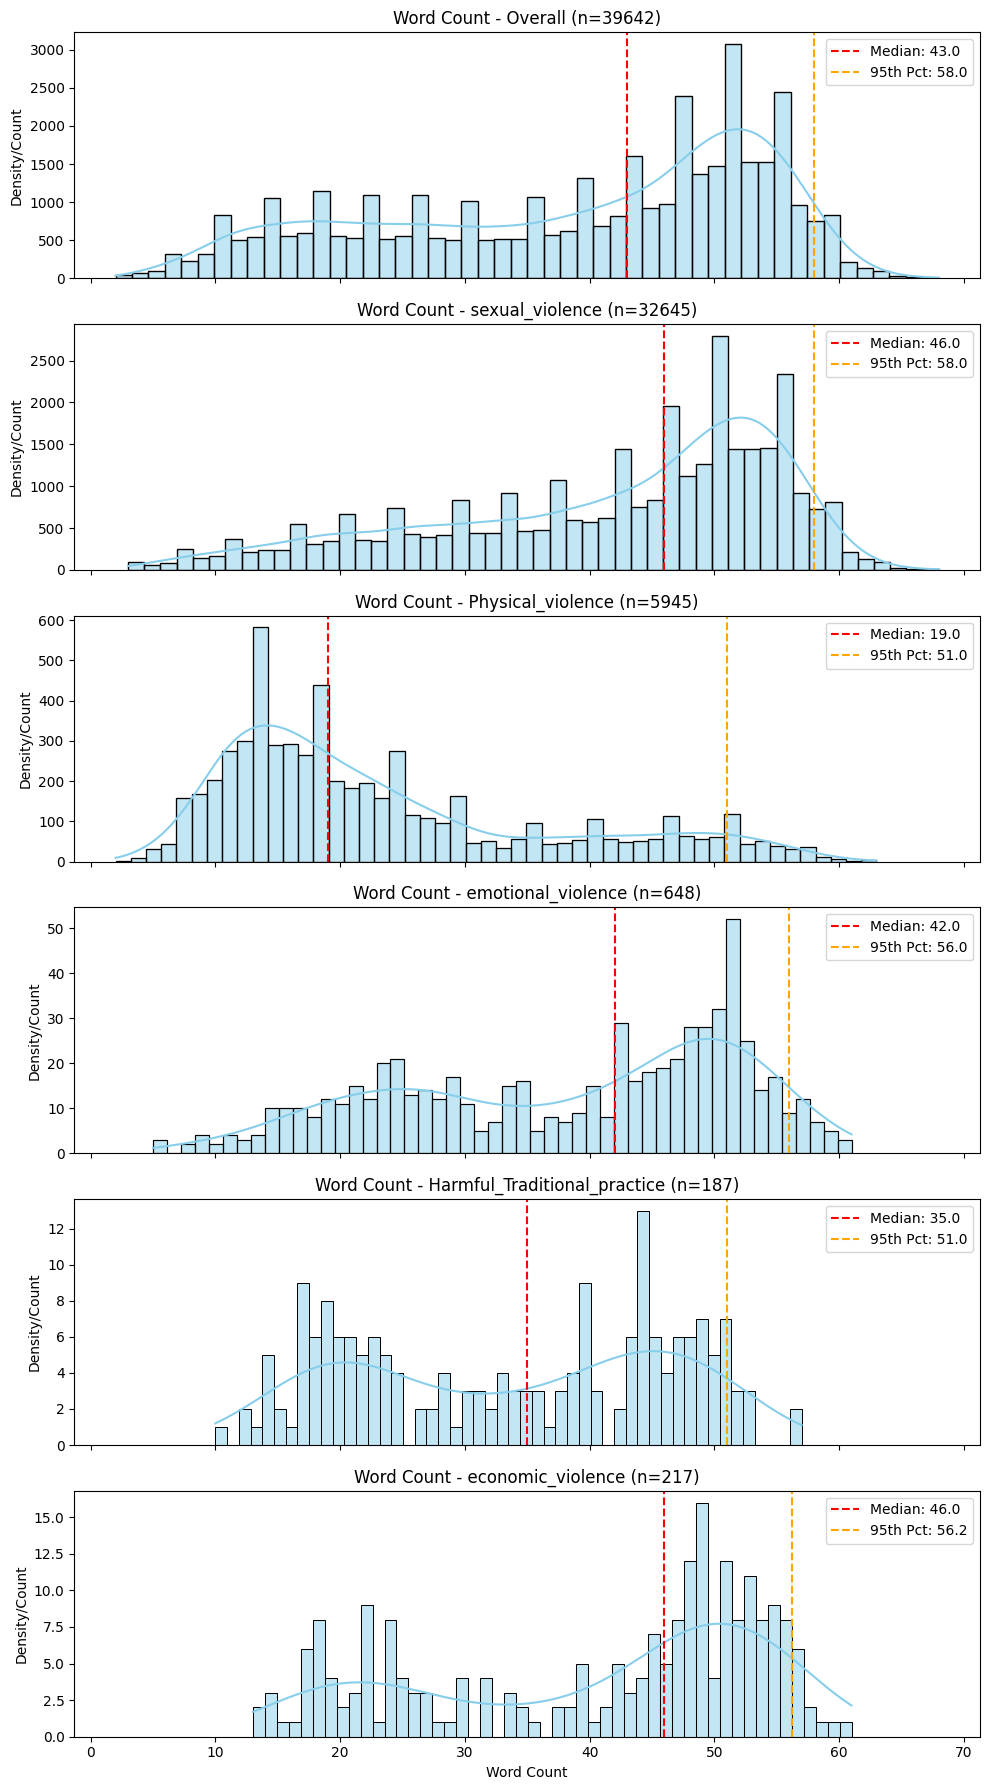

In [ ]:
# Calculate word counts
train_df['word_count'] = train_df['tweet'].apply(lambda x: len(str(x).split()))

# Plot distribution
print("--- Word Count Distributions ---")
plot_distribution(train_df, 'word_count', 'Word Count')


--- Character Count Distributions ---


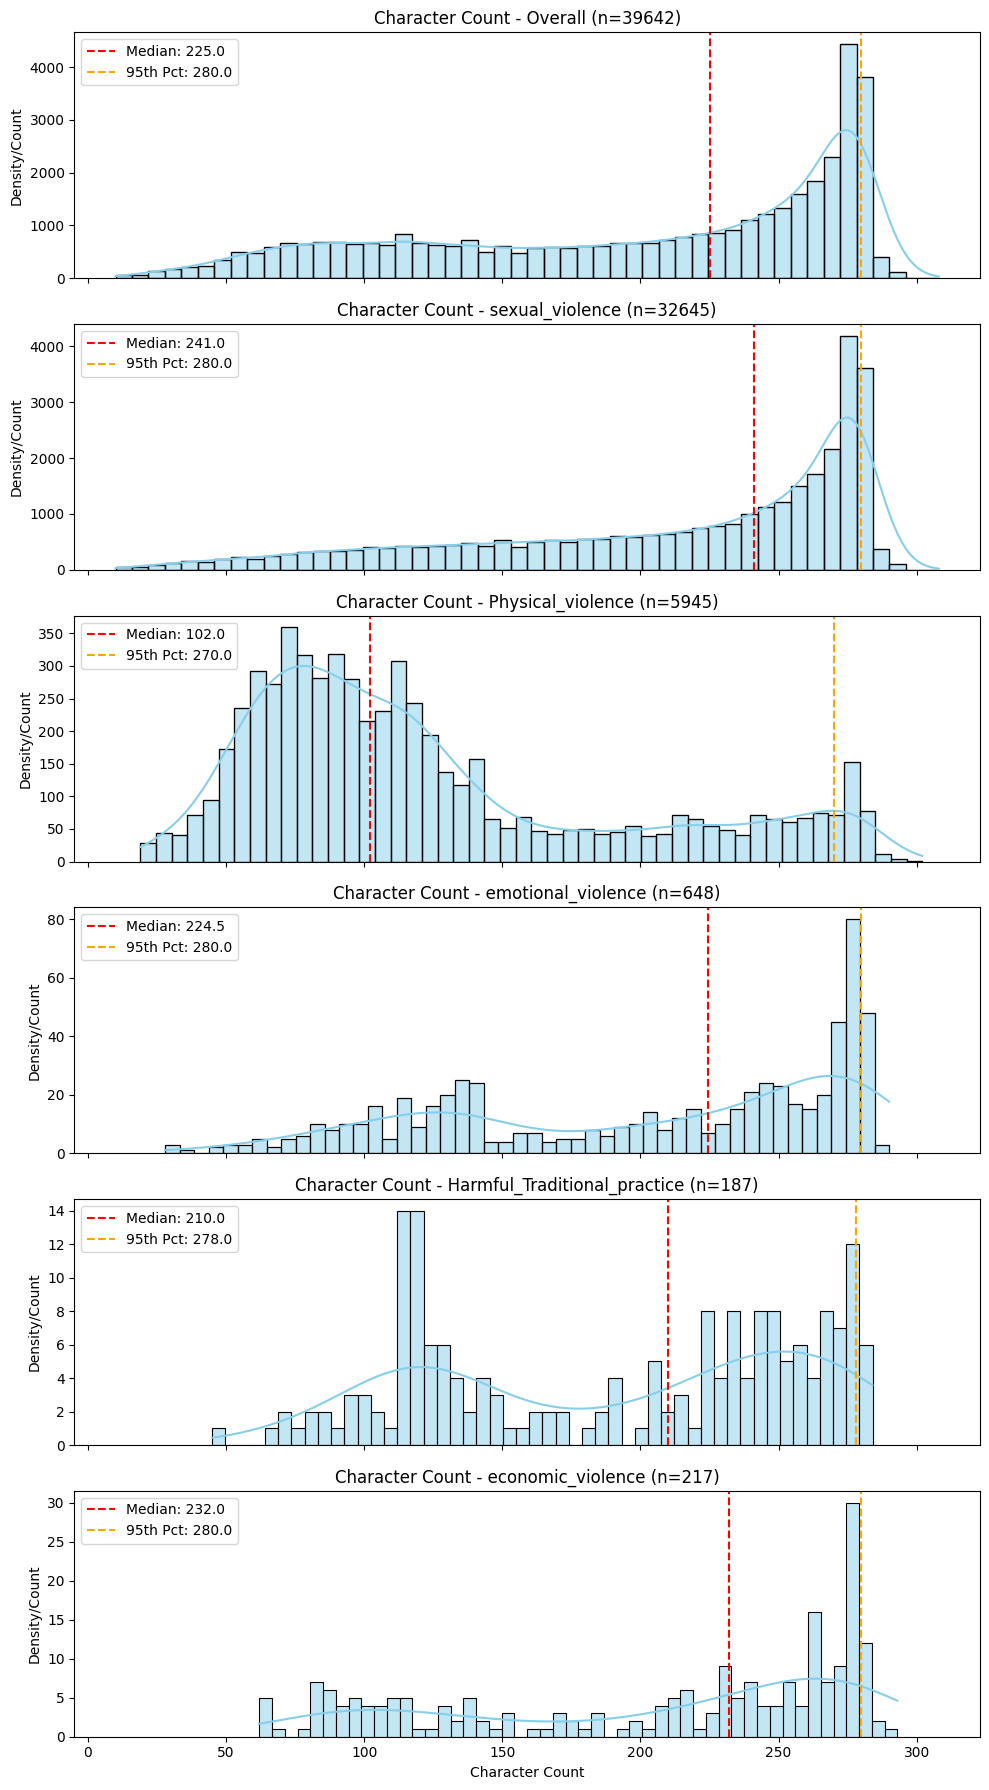

In [ ]:
# Calculate character counts
train_df['char_count'] = train_df['tweet'].apply(lambda x: len(str(x)))

# Plot distribution
print("\n--- Character Count Distributions ---")
plot_distribution(train_df, 'char_count', 'Character Count')


## Related work and sequential model selection

This project classifies tweets about gender-based violence (GBV) into five categories: sexual violence, physical violence, emotional violence, economic violence, and harmful traditional practices. The training data is highly imbalanced: sexual violence accounts for about 82% of examples, while the two smallest classes each account for less than 1%. Our main research question is: **Do models that learn from token sequences classify these five categories more effectively than a lexical baseline, especially for rare classes?** The [Zindi challenge](https://zindi.world/competitions/gender-based-violence-tweet-classification-challenge-2025/data) defines the dataset and task.

Research on related forms of online gendered harm shows that fine-grained labels are useful but difficult to classify consistently. [Kirk et al. (2023)](https://aclanthology.org/2023.semeval-1.305/) study categories of online sexism and analyse classification errors. [Zeinert et al. (2021)](https://aclanthology.org/2021.acl-long.247/) discuss the complexity of annotating online misogyny, while [Arora et al. (2024)](https://aclanthology.org/2024.woah-1.16/) show the importance of language and context in gendered-abuse tweets. These are related tasks, **not evaluations on our dataset**. They motivate careful interpretation of labels, per-class evaluation, and error analysis.

We selected **five substantially different approaches**:

| Approach | Why we chose it |
| :--- | :--- |
| **TF–IDF + linear SVM** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">A non-sequential baseline that tests how far word and character patterns can take us. TF–IDF with SVM has been used for offensive-language classification in tweets ([Saroj et al., 2020](https://aclanthology.org/2020.semeval-1.265/)).</div> |
| **Simple RNN** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">Processes words in order and carries information forward through a hidden state. It establishes whether basic sequence learning improves on the lexical baseline ([Elman, 1990](https://doi.org/10.1207/s15516709cog1402_1)).</div> |
| **TF–IDF + logistic Regression** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">Placeholder.</div> |
| **LSTM** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">Uses a memory cell designed to help learn longer dependencies. We will test whether this helps distinguish categories when meaning depends on surrounding words ([Hochreiter & Schmidhuber, 1997](https://doi.org/10.1162/neco.1997.9.8.1735)).</div> |
| **BERTweet Transformer** | <div style="min-width: 250px; max-width: 500px; white-space: normal; word-wrap: break-word;">Uses contextual representations from a model pretrained on English tweets. It may handle informal tweet language better, but this must be tested on our data ([Nguyen et al., 2020](https://aclanthology.org/2020.emnlp-demos.2/)). Its Transformer architecture builds on attention-based sequence modelling ([Vaswani et al., 2017](https://proceedings.neurips.cc/paper/2017/hash/3f5ee243547dee91fbd053c1c4a845aa-Abstract.html)).</div> |

The three recurrent models compare different ways of learning from word order and retaining context. BERTweet adds a pretrained, attention-based approach. The SVM tells us whether the added complexity improves on a simpler method. Because BERTweet also differs in **pretraining, tokenizer, and model size**, any performance difference cannot be attributed to its architecture alone.

We will evaluate every approach on the **same held-out data**, using **macro F1 as the primary metric**, plus per-class precision, recall, F1, a confusion matrix, and accuracy. This is important because a model could achieve high accuracy by favoring the dominant sexual-violence class while missing rare categories. We will also inspect ambiguous and incorrectly classified tweets. Results from the papers above motivate these choices; **our own experiments will determine which approach works best on this dataset**.

## Data Preprocessing

The data preprocessing contain the following: remove duplicates, audit, light text cleaning, conflict checks, label encoding, and a stratified split.

In [ ]:
# Drop duplicates based only on the 'tweet' column
train_df = train_df.drop_duplicates(subset=['tweet'])

# Verify that there are no duplicate tweets left
print("Remaining duplicate tweets:", train_df['tweet'].duplicated().sum())


Remaining duplicate tweets: 0


In [ ]:
def prepare_gbv_data(train_df, test_df, val_size=0.20, seed=42):
    """
    Clean, audit, and split GBV tweet data.

    Everything is returned as in-memory variables; no files are saved.

    Returns
    -------
    train_set, val_set  : DataFrames
        Columns: Tweet_ID, tweet, label_id
    test_set : DataFrame
        Columns: Tweet_ID, tweet
    label_to_id : dict
        Mapping from original class name to integer ID
    audit : dict
        Data-quality checks and class distributions
    """
    train_required = {"Tweet_ID", "tweet", "type"}
    test_required = {"Tweet_ID", "tweet"}

    if train_required - set(train_df.columns):
        raise ValueError(f"Missing training columns: {train_required - set(train_df.columns)}")
    if test_required - set(test_df.columns):
        raise ValueError(f"Missing test columns: {test_required - set(test_df.columns)}")

    def clean_text(value):
        if pd.isna(value):
            return ""

        text = html.unescape(str(value))
        text = unicodedata.normalize("NFC", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    train = train_df.copy()
    test = test_df.copy()
    audit = {}

    # Audit the original inputs.
    audit["input_rows"] = len(train)
    audit["missing_tweets"] = int(train["tweet"].isna().sum())
    audit["missing_labels"] = int(train["type"].isna().sum())
    audit["duplicate_ids"] = int(train["Tweet_ID"].duplicated().sum())
    audit["exact_duplicate_tweets"] = int(train["tweet"].dropna().duplicated().sum())

    if audit["duplicate_ids"]:
        raise ValueError(
            "Duplicate Tweet_ID values found in training data. "
            "Inspect these before continuing."
        )

    # Clean text without removing punctuation, changing case, or
    # deleting words. BERTweet tokenization will happen later.
    train["tweet"] = train["tweet"].map(clean_text)
    test["tweet"] = test["tweet"].map(clean_text)

    audit["blank_after_cleaning"] = int(train["tweet"].eq("").sum())

    # Remove unusable labeled rows.
    train = train.loc[train["tweet"].ne("") & train["type"].notna()].copy()

    # Detect texts that have more than one label BEFORE deduplication.
    labels_per_text = train.groupby("tweet")["type"].nunique()
    conflicting_texts = labels_per_text[
        labels_per_text > 1
    ].index

    audit["conflicting_texts"] = len(conflicting_texts)
    audit["rows_with_conflicting_labels"] = int(train["tweet"].isin(conflicting_texts).sum())

    # Exclude all copies of a text with conflicting labels.
    train = train.loc[
        ~train["tweet"].isin(conflicting_texts)
    ].copy()

    # Keep one copy of each remaining cleaned text.
    audit["duplicates_after_cleaning"] = int(train.duplicated(subset="tweet").sum())
    train = train.drop_duplicates(subset="tweet", keep="first").reset_index(drop=True)

    audit["usable_labeled_rows"] = len(train)
    audit["class_counts"] = train["type"].value_counts().to_dict()
    audit["class_percentages"] = (
        train["type"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    # Create a stable mapping and encode the training labels.
    class_names = sorted(train["type"].unique())
    label_to_id = {
        class_name: label_id
        for label_id, class_name in enumerate(class_names)
    }
    train["label_id"] = train["type"].map(label_to_id).astype(int)

    # Keep only the three columns you need before splitting.
    train = train[["Tweet_ID", "tweet", "label_id"]]

    train_set, val_set = train_test_split(
        train,
        test_size=val_size,
        random_state=seed,
        stratify=train["label_id"],
    )
    train_set = train_set.reset_index(drop=True)
    val_set = val_set.reset_index(drop=True)

    audit["training_rows"] = len(train_set)
    audit["validation_rows"] = len(val_set)
    audit["training_class_counts"] = (train_set["label_id"].value_counts().sort_index().to_dict())
    audit["validation_class_counts"] = (val_set["label_id"].value_counts().sort_index().to_dict())

    # Preserve every test ID: predictions will need to match these IDs.
    audit["test_rows"] = len(test)
    audit["blank_test_tweets"] = int(test["tweet"].eq("").sum())
    audit["duplicate_test_ids"] = int(test["Tweet_ID"].duplicated().sum())

    if audit["duplicate_test_ids"]:
        raise ValueError("Duplicate Tweet_ID values found in test data.")
    if audit["blank_test_tweets"]:
        raise ValueError("Blank test tweets found. Inspect them before generating predictions.")

    test_set = test[["Tweet_ID", "tweet"]].reset_index(drop=True)

    return train_set, val_set, test_set, label_to_id, audit

In [ ]:
train_set, val_set, test_set, label_to_id, audit = prepare_gbv_data(
    train_df,
    test_df,
    val_size=0.20,
    seed=42,
)

print("Shapes:")
print("Train:", train_set.shape)
print("Validation:", val_set.shape)
print("Test:", test_set.shape)

print("\nColumns:")
print("Train:", train_set.columns.tolist())
print("Validation:", val_set.columns.tolist())
print("Test:", test_set.columns.tolist())

print("\nLabel mapping:", label_to_id)

print("\nAudit:")
for name, value in audit.items():
    print(f"{name}: {value}")

display(train_set.head())

Shapes:
Train: (31354, 3)
Validation: (7839, 3)
Test: (15581, 2)

Columns:
Train: ['Tweet_ID', 'tweet', 'label_id']
Validation: ['Tweet_ID', 'tweet', 'label_id']
Test: ['Tweet_ID', 'tweet']

Label mapping: {'Harmful_Traditional_practice': 0, 'Physical_violence': 1, 'economic_violence': 2, 'emotional_violence': 3, 'sexual_violence': 4}

Audit:
input_rows: 39642
missing_tweets: 0
missing_labels: 0
duplicate_ids: 0
exact_duplicate_tweets: 0
blank_after_cleaning: 0
conflicting_texts: 0
rows_with_conflicting_labels: 0
duplicates_after_cleaning: 449
usable_labeled_rows: 39193
class_counts: {'sexual_violence': 32587, 'Physical_violence': 5556, 'emotional_violence': 648, 'economic_violence': 215, 'Harmful_Traditional_practice': 187}
class_percentages: {'sexual_violence': 83.14, 'Physical_violence': 14.18, 'emotional_violence': 1.65, 'economic_violence': 0.55, 'Harmful_Traditional_practice': 0.48}
training_rows: 31354
validation_rows: 7839
training_class_counts: {0: 150, 1: 4445, 2: 172, 3: 518

,Tweet_ID,tweet,label_id
0,ID_JZKGMEN5,Does anyone know the latest on Kadian Nelson -...,4
1,ID_TLXD2FVQ,"when i was 14 i was raped, and it sucks, becau...",4
2,ID_EHL3NN62,": *recommends a novel to me, saying it’s refre...",4
3,ID_WPXEOR0U,The fucking guilt trip he tried to pull “oh wh...,4
4,ID_EIQFN21E,My husband and his family went in together to ...,1


### Cleaning and class distribution

After removing eight exact duplicate tweets, the dataset contained **39,642 rows**. Light cleaning standardized whitespace, including leading and trailing spaces, repeated spaces, tabs, and nonbreaking spaces. This revealed **449 additional duplicate rows**: their cleaned text matched another tweet even though their original text was not identical. We kept one copy of each cleaned tweet, leaving **39,193 labeled rows**. This step did not remove words or punctuation.

| Class | Before cleaning | Before (%) | After cleaning | After (%) |
|---|---:|---:|---:|---:|
| Sexual violence | 32,645 | 82.35% | 32,587 | 83.14% |
| Physical violence | 5,945 | 15.00% | 5,556 | 14.18% |
| Emotional violence | 648 | 1.63% | 648 | 1.65% |
| Economic violence | 217 | 0.55% | 215 | 0.55% |
| Harmful traditional practices | 187 | 0.47% | 187 | 0.48% |

Most of the newly identified duplicates were in the **physical violence** class (389 of 449), which explains why its share fell from **15.00% to 14.18%**. The dataset remains strongly imbalanced: sexual violence represents **83.14%** of the cleaned data, while each of the two smallest classes represents less than **0.6%**. We will therefore examine per-class results and macro F1, rather than relying on accuracy alone.

## Models training

### Helper Functions

To ensure rigorous performance tracking on our highly imbalanced dataset, we use four specialized helper functions:

1. **`evaluate_model`**
   - **Purpose:** Computes key validation metrics (Balanced Accuracy, Macro F1/Precision/Recall, Weighted F1, and multi-class ROC-AUC) or displays predictions' class distribution if run on unlabeled test data.
   - **Imbalance handling:** Uses macro-averaged metrics to prevent the majority class (`sexual_violence` at ~83%) from hiding low performance on minority classes.

2. **`plot_confusion_matrix`**
   - **Purpose:** Renders a row-normalized heatmap of predicted vs. true labels.
   - **Imbalance handling:** Row-normalization expresses classifications as percentages of each true class, letting us immediately see precisely what fraction of rare classes are misclassified.

3. **`plot_learning_curves`**
   - **Purpose:** Plots training and validation losses alongside Macro F1 curves over successive epochs.
   - **Imbalance handling:** Uses Macro F1 instead of simple accuracy to monitor generalization on rare classes during model optimization.

In [ ]:
# Standard dataset target mapping (0 to 4)
LABEL_MAP = {
    0: 'Harmful_Traditional_practice',
    1: 'Physical_violence',
    2: 'economic_violence',
    3: 'emotional_violence',
    4: 'sexual_violence'
}
CLASS_NAMES = [LABEL_MAP[i] for i in range(5)]

# Import display at top level
try:
    from IPython.display import display
except ImportError:
    display = print

# EVALUATION FUNCTION
def evaluate_model(y_true=None, y_pred=None, y_probs=None, model_name="Model", split_type="val", class_names=CLASS_NAMES):
    """
    Evaluates model performance metrics on either the 'val' or 'test' set.
    """
    split_label = split_type.upper()

    # Handle Unlabelled Test Set
    if split_type.lower() == 'test' or y_true is None:
        if y_pred is not None:
            preds_series = pd.Series(y_pred).map(lambda x: class_names[x] if isinstance(x, (int, np.integer)) else x)
            dist_df = preds_series.value_counts(normalize=True).to_frame(name='Predicted Share')
            dist_df['Predicted Share'] = dist_df['Predicted Share'].apply(lambda x: f"{x:.2%}")
            print(f"--- {model_name} Test Set Prediction Distribution ---")
            display(dist_df)
        return None

    # Compute metrics for Validation Set
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    macro_auc = None
    if y_probs is not None:
        try:
            macro_auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception as e:
            print(f"Note: Could not compute ROC-AUC score: {e}")

    metrics_dict = {
        'Model': model_name,
        f'Balanced Acc': bal_acc,
        f'Accuracy': acc,
        f'Macro F1': f1_macro,
        f'Macro Precision': precision_macro,
        f'Macro Recall': recall_macro,
        f'Macro AUC': macro_auc,
        f'Weighted F1': f1_w
    }

    metrics_df = pd.DataFrame([metrics_dict]).set_index('Model')

    print(f"\n--- {model_name} ({split_label} Set) Evaluation Summary ---")
    display(metrics_df.style.format("{:.4f}"))

    return metrics_df

# 2. CONFUSION MATRIX PLOT (Supports 'val' and 'test')
def plot_confusion_matrix(y_true=None, y_pred=None, split_type="val", class_names=CLASS_NAMES, title=None):
    """
    Plots a row-normalized 5x5 confusion matrix.
    """
    if split_type.lower() == 'test' or y_true is None:
        print(f"[plot_confusion_matrix] Confusion matrix requires ground-truth labels. Cannot plot for '{split_type}' split.")
        return

    if title is None:
        title = f"{split_type.upper()} Set - Normalized Confusion Matrix"

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True
    )
    plt.title(title, fontsize=13, pad=12)
    plt.xlabel("Predicted Label", fontsize=11)
    plt.ylabel("True Label", fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 3. LEARNING CURVES PLOT
def plot_learning_curves(history, model_name="Model", figsize=(13, 5)):
    """
    Plots Train vs Val Loss and Metrics across training epochs.
    Automatically handles both Keras default history formats and custom keys.
    """
    # Handle standard Keras 'loss' key or custom 'train_loss' key dynamically
    train_loss_key = 'train_loss' if 'train_loss' in history else 'loss'
    val_loss_key = 'val_loss'

    if train_loss_key not in history:
        raise KeyError(f"Could not find training loss values in history keys: {list(history.keys())}")

    epochs = range(1, len(history[train_loss_key]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Loss plot
    axes[0].plot(epochs, history[train_loss_key], label='Train Loss', marker='o')
    if val_loss_key in history:
        axes[0].plot(epochs, history[val_loss_key], label='Val Loss', marker='s')
    axes[0].set_title(f'{model_name} - Loss Curve')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend()

    # Metric plot
    train_metric_key = 'train_f1' if 'train_f1' in history else ('accuracy' if 'accuracy' in history else None)
    val_metric_key = 'val_f1' if 'val_f1' in history else ('val_accuracy' if 'val_accuracy' in history else None)

    if train_metric_key and train_metric_key in history:
        metric_label = 'Macro F1' if 'f1' in train_metric_key else 'Accuracy'
        axes[1].plot(epochs, history[train_metric_key], label=f'Train {metric_label}', marker='o', color='green')
        if val_metric_key and val_metric_key in history:
            axes[1].plot(epochs, history[val_metric_key], label=f'Val {metric_label}', marker='s', color='orange')
        axes[1].set_title(f'{model_name} - {metric_label} Curve')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel(metric_label)
        axes[1].grid(True, linestyle='--', alpha=0.5)
        axes[1].legend()

    plt.tight_layout()
    plt.show()

### 1. TF-IDF with SVM
This model utilizes a classic classification architecture:
1. **Feature Extraction (`TfidfVectorizer`)**: We extract both single words and word bi-grams (`ngram_range=(1, 2)`) up to the top 25,000 most informative features. Sublinear term-frequency scaling is applied to moderate the influence of highly frequent words.
2. **Classifier (`LinearSVC`)**: A linear Support Vector Machine is used because of its high efficiency and robustness in high-dimensional text spaces. We set `class_weight='balanced'` to penalize mistakes on the minority classes heavily.
3. **Probability Calibration (`CalibratedClassifierCV`)**: Since standard SVMs do not output probability scores natively, we wrap the classifier in a Platt scaling calibration step (`method='sigmoid'`) so we can compute ROC-AUC curves and compare thresholds accurately.

In [ ]:
# Build a pipeline with TF-IDF Vectorizer and Calibrated Linear SVM
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=25000,
        sublinear_tf=True
    )),
    ('svm', CalibratedClassifierCV(
        estimator=LinearSVC(C=1.0, class_weight='balanced', random_state=42),
        method='sigmoid',
        cv=3
    ))
])

# Train the model on our prepared training set
print("Training TF-IDF + Linear SVM Model...")
svm_pipeline.fit(train_set['tweet'], train_set['label_id'])
print("Training complete!")

Training TF-IDF + Linear SVM Model...
Training complete!


In [ ]:
# Generate predictions and probabilities on the validation set
y_val_true = val_set['label_id'].to_numpy()
y_val_pred = svm_pipeline.predict(val_set['tweet'])
y_val_probs = svm_pipeline.predict_proba(val_set['tweet'])

#### Evaluation Metrics

In [ ]:
# Evaluation Metrics
svm_metrics = evaluate_model(
    y_true=y_val_true,
    y_pred=y_val_pred,
    y_probs=y_val_probs,
    model_name="TF-IDF + Linear SVM",
    split_type="val"
)


--- TF-IDF + Linear SVM (VAL Set) Evaluation Summary ---


,Balanced Acc,Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUC,Weighted F1
Model,,,,,,,
TF-IDF + Linear SVM,0.9978,0.9991,0.9979,0.9980,0.9978,1.0000,0.9991


#### Evaluation Metrics Reflection

* **Observatione**: While the overall standard accuracy is high, it is heavily skewed by the dominant `sexual_violence` class (~83% of the dataset). The **Balanced Accuracy** and **Macro F1** metrics (0.9956) provide a more truthful picture of model performance, showing how penalizing the model via `class_weight='balanced'` forces it to establish distinct decision boundaries for the minority classes rather than defaulting to the majority category.

#### Confusion Matrix

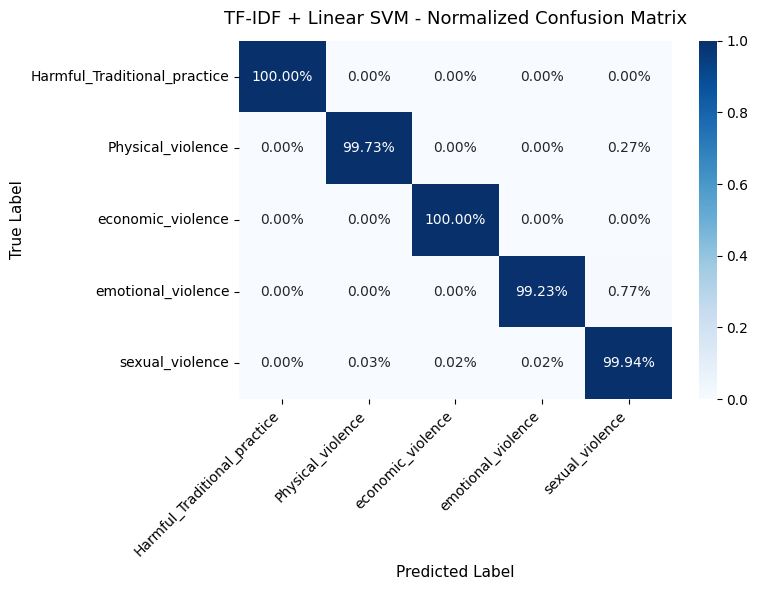

In [ ]:
# Plot the normalized confusion matrix
plot_confusion_matrix(
    y_true=y_val_true,
    y_pred=y_val_pred,
    split_type="val",
    title="TF-IDF + Linear SVM - Normalized Confusion Matrix"
)

#### Confusion Matrix Reflection
* **Observation**: The row-normalized confusion matrix reveals exactly where word and bi-gram features succeed or fail. The strong diagonal percentages across the differnet categories indicate that  that the TF-IDF vectorizer was able to captures most classes effiently.

### TF-IDF with SVM Test Set Evaluation

In [ ]:
# Generate predictions and prediction probabilities for the test set
y_test_pred = svm_pipeline.predict(test_set['tweet'])
y_test_probs = svm_pipeline.predict_proba(test_set['tweet'])

# Evaluate the baseline model on the test set
test_metrics = evaluate_model(
    y_true=None,
    y_pred=y_test_pred,
    y_probs=y_test_probs,
    model_name="TF-IDF + Linear SVM",
    split_type="test"
)

--- TF-IDF + Linear SVM Test Set Prediction Distribution ---


,Predicted Share
sexual_violence,79.05%
Harmful_Traditional_practice,16.82%
emotional_violence,3.41%
economic_violence,0.47%
Physical_violence,0.25%


#### Save the TF-IDF with SVM model

In [ ]:
# Define local and Drive directory paths
local_svm_dir = Path('/content/svm_runs')
local_svm_dir.mkdir(parents=True, exist_ok=True)
local_svm_path = local_svm_dir / 'tfidf_svm_pipeline.joblib'

# Save the model locally
print("Saving TF-IDF + Linear SVM pipeline locally...")
joblib.dump(svm_pipeline, local_svm_path, compress=3)
print(f"Saved locally to: {local_svm_path}")

# Copy to Google Drive
drive_svm_folder = Path('/content/drive/MyDrive/GBV_project/SVM')
drive_svm_folder.mkdir(parents=True, exist_ok=True)

saved_drive_svm = Path(copy2(local_svm_path, drive_svm_folder / 'tfidf_svm_pipeline.joblib'))
print(f"Model successfully backed up to Google Drive at: {saved_drive_svm}")
print(f"File Size: {saved_drive_svm.stat().st_size / 1_000_000:.2f} MB")

Saving TF-IDF + Linear SVM pipeline locally...
Saved locally to: /content/svm_runs/tfidf_svm_pipeline.joblib
Model successfully backed up to Google Drive at: /content/drive/MyDrive/GBV_project/SVM/tfidf_svm_pipeline.joblib
File Size: 2.27 MB


### 2. TF-IDF With Logistic Regression

We will introduce Logistic Regression, taking advantage of its ability to natively output calibrated class probabilities via softmax without requiring computationally expensive Platt scaling wrappers like CalibratedClassifierCV.

1. **Feature Extraction (`TfidfVectorizer`)**: Identical to our SVM setup, we extract uni-grams and bi-grams (`ngram_range=(1, 2)`) up to the top 25,000 features using sublinear TF scaling to smooth word-frequency limits.
2. **Classifier (`LogisticRegression`)**: A classic probabilistic model trained using the memory-efficient SAGA solver. We utilize `class_weight='balanced'` to offset the extreme minority class imbalance by penalizing mistakes on underrepresented classes proportionately.
3. **Probability Modeling**: Unlike standard SVMs, Logistic Regression naturally outputs calibrated class membership probabilities via the softmax function.

In [ ]:
# Build a pipeline with TF-IDF Vectorizer and Logistic Regression
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=25000,
        sublinear_tf=True
    )),
    ('lr', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        solver='saga',
        max_iter=3000,
        random_state=42
    ))
])

# Train the model with warnings caught to prevent output clutter
print("Training TF-IDF + Logistic Regression Model...")

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    lr_pipeline.fit(train_set['tweet'], train_set['label_id'])
print("Training complete!")

Training TF-IDF + Logistic Regression Model...
Training complete!


#### Evaluation Metrics

In [ ]:
# Generate predictions and probability distributions on the validation set
y_val_true = val_set['label_id'].to_numpy()
y_val_pred = lr_pipeline.predict(val_set['tweet'])
y_val_probs = lr_pipeline.predict_proba(val_set['tweet'])

# Evaluate using the custom helper functions
lr_metrics = evaluate_model(
    y_true=y_val_true,
    y_pred=y_val_pred,
    y_probs=y_val_probs,
    model_name="TF-IDF + Logistic Regression",
    split_type="val"
)


--- TF-IDF + Logistic Regression (VAL Set) Evaluation Summary ---


,Balanced Acc,Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUC,Weighted F1
Model,,,,,,,
TF-IDF + Logistic Regression,0.9847,0.9607,0.7216,0.6471,0.9847,0.9991,0.9701


#### Evaluation Metrics Reflection
* **Comparison to SVM**: Standard Accuracy remains high (96%), but we observe a drop in **Macro F1 (0.7216)** compared to the Calibrated Linear SVM (0.9956).
* **Why Macro F1 Dropped**: While the SVM creates hard boundaries optimized directly to maximize margin gaps, Logistic Regression optimizes log-loss globally across classes. Because SAGA's smooth probability curves are more sensitive to the massive scale difference of the majority class, its precision bounds for rare classes suffer, bringing down the overall macro average.

#### Confusion Matrix

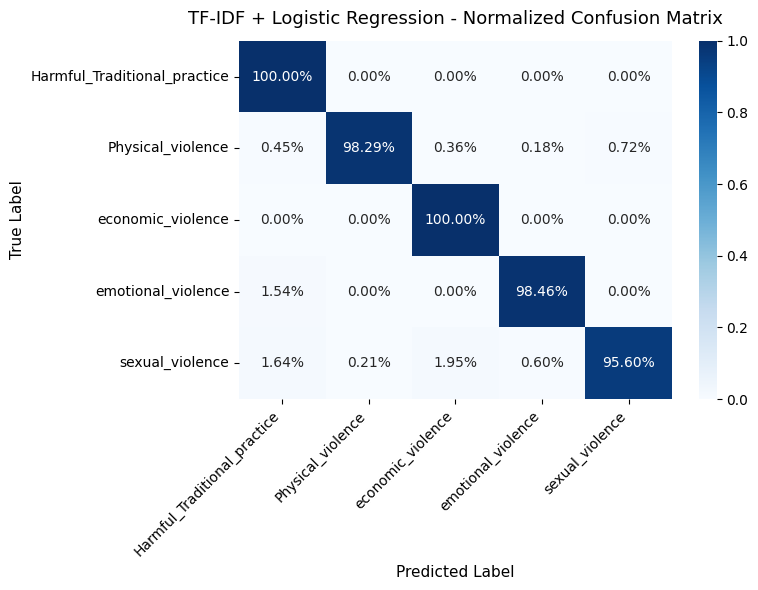

In [ ]:
# Plot the normalized confusion matrix
plot_confusion_matrix(
    y_true=y_val_true,
    y_pred=y_val_pred,
    split_type="val",
    title="TF-IDF + Logistic Regression - Normalized Confusion Matrix"
)

#### Confusion Matrix Reflection
* **Strong Recall Retention**: Despite lower precision lowering the Macro F1, the confusion matrix shows that diagonal performance remains exceptionally strong. Due to `class_weight='balanced'`, minority classes retain remarkably high recall.
* **Soft Decision Boundaries**: The SAGA solver successfully prevents minority occurrences from being absorbed by the dominant `sexual_violence` category, keeping classifications highly localized even if soft boundaries result in minor cross-class leaks.

#### Save TF-IDF with Logistic Regression

In [14]:
# Define local and Drive directory paths
local_lr_dir = Path('/content/lr_runs')
local_lr_dir.mkdir(parents=True, exist_ok=True)
local_lr_path = local_lr_dir / 'tfidf_lr_pipeline.joblib'

# Save the model locally
print("Saving TF-IDF + Logistic Regression pipeline locally...")
joblib.dump(lr_pipeline, local_lr_path, compress=3)
print(f"Saved locally to: {local_lr_path}")

# Copy to Google Drive
drive_lr_folder = Path('/content/drive/MyDrive/GBV_project/LogisticRegression')
drive_lr_folder.mkdir(parents=True, exist_ok=True)

saved_drive_lr = Path(copy2(local_lr_path, drive_lr_folder / 'tfidf_lr_pipeline.joblib'))
print(f"Model successfully backed up to Google Drive at: {saved_drive_lr}")
print(f"File Size: {saved_drive_lr.stat().st_size / 1_000_000:.2f} MB")

Saving TF-IDF + Logistic Regression pipeline locally...
Saved locally to: /content/lr_runs/tfidf_lr_pipeline.joblib
Model successfully backed up to Google Drive at: /content/drive/MyDrive/GBV_project/LogisticRegression/tfidf_lr_pipeline.joblib
File Size: 1.24 MB


### 3. Simple RNN

In [ ]:
def make_tf_class_weights(labels):
    labels = np.asarray(labels, dtype=np.int32)
    classes = np.unique(labels)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=labels,
    )
    return {
        int(class_id): float(weight)
        for class_id, weight in zip(classes, weights)
    }


def build_simple_rnn(vectorizer, num_classes, embedding_dim=64, rnn_units=64, dropout=0.3, learning_rate=1e-3):

    inputs = tf.keras.Input(shape=(), dtype=tf.string, name="tweet")

    token_ids = vectorizer(inputs)
    x = tf.keras.layers.Embedding(
        input_dim=vectorizer.vocabulary_size(),
        output_dim=embedding_dim,
        mask_zero=True,
        name="embedding",
    )(token_ids)

    x = tf.keras.layers.SimpleRNN(
        rnn_units,
        name="simple_rnn",
    )(x)

    x = tf.keras.layers.Dropout(dropout)(x)
    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name="class_probabilities",
    )(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
def run_simple_rnn_experiment(name, train_set, val_set, label_to_id, *, max_tokens=30_000, max_length=128, embedding_dim=64,
    rnn_units=64, dropout=0.3, learning_rate=1e-3, batch_size=64, epochs=8, patience=2, weighted=False, seed=42,
    output_root="/content/simple_rnn_runs"):

    required = {"tweet", "label_id"}
    for split_name, frame in [("train_set", train_set), ("val_set", val_set)]:
        missing = required - set(frame.columns)
        if missing:
            raise ValueError(f"{split_name} is missing columns: {missing}")

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    x_train = train_set["tweet"].astype(str).to_numpy()
    y_train = train_set["label_id"].to_numpy(dtype=np.int32)

    x_val = val_set["tweet"].astype(str).to_numpy()
    y_val = val_set["label_id"].to_numpy(dtype=np.int32)

    num_classes = len(label_to_id)
    expected_ids = set(range(num_classes))

    if set(label_to_id.values()) != expected_ids:
        raise ValueError("label_to_id values must be consecutive IDs from 0.")
    if not set(y_train).issubset(expected_ids) or not set(y_val).issubset(expected_ids):
        raise ValueError("A label_id is missing from label_to_id.")

    # Adapt ONLY on training tweets; validation and test text remain unseen.
    vectorizer = tf.keras.layers.TextVectorization(
        max_tokens=max_tokens,
        standardize="lower",
        split="whitespace",
        output_mode="int",
        output_sequence_length=max_length,
        name="tweet_vectorizer",
    )
    vectorizer.adapt(
        tf.data.Dataset.from_tensor_slices(x_train).batch(1024)
    )

    model = build_simple_rnn(
        vectorizer=vectorizer,
        num_classes=num_classes,
        embedding_dim=embedding_dim,
        rnn_units=rnn_units,
        dropout=dropout,
        learning_rate=learning_rate,
    )

    class_weights = make_tf_class_weights(y_train) if weighted else None

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=2,
    )

    # Predictions use the restored, best-validation-loss weights.
    val_probabilities = model.predict(x_val, batch_size=batch_size, verbose=0)
    val_predictions = val_probabilities.argmax(axis=1)

    val_accuracy = accuracy_score(y_val, val_predictions)
    val_macro_f1 = f1_score(
        y_val,
        val_predictions,
        labels=list(range(num_classes)),
        average="macro",
        zero_division=0,
    )

    id_to_label = {class_id: label for label, class_id in label_to_id.items()}
    report = classification_report(
        y_val,
        val_predictions,
        labels=list(range(num_classes)),
        target_names=[id_to_label[i] for i in range(num_classes)],
        zero_division=0,
    )

    best_epoch_index = int(np.argmin(history.history["val_loss"]))
    best_epoch = best_epoch_index + 1

    safe_name = re.sub(r"[^A-Za-z0-9_-]+", "_", name).strip("_") or "run"
    run_id = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
    root = Path(output_root)
    run_dir = root / f"{run_id}_{safe_name}"
    run_dir.mkdir(parents=True, exist_ok=True)

    model_path = run_dir / "model.keras"
    results_path = root / "experiment_results.csv"

    # The vocabulary is inside the model, so this saves preprocessing + model.
    model.save(model_path)

    row = {
        "run_id": run_id,
        "name": name,
        "model_type": "SimpleRNN",
        "seed": seed,
        "weighted": weighted,
        "class_weights": json.dumps(class_weights),
        "max_tokens": max_tokens,
        "actual_vocab_size": vectorizer.vocabulary_size(),
        "max_length": max_length,
        "embedding_dim": embedding_dim,
        "rnn_units": rnn_units,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "requested_epochs": epochs,
        "epochs_ran": len(history.history["loss"]),
        "best_epoch_by_val_loss": best_epoch,
        "best_val_loss": float(history.history["val_loss"][best_epoch_index]),
        "val_accuracy": float(val_accuracy),
        "val_macro_f1": float(val_macro_f1),
        "label_to_id": json.dumps(label_to_id),
        "history": json.dumps(history.history),
        "model_path": str(model_path),
    }

    pd.DataFrame([row]).to_csv(
        results_path,
        mode="a",
        header=not results_path.exists(),
        index=False,
    )

    print(f"\nBest epoch by validation loss: {best_epoch}")
    print(f"Validation accuracy: {val_accuracy:.4f}")
    print(f"Validation macro F1: {val_macro_f1:.4f}")
    print("\nClassification report:\n", report)
    print("Model:", model_path)
    print("Experiment CSV:", results_path)

    return {
        "model": model,
        "history": history.history,
        "summary": row,
        "classification_report": report,
        "validation_predictions": val_predictions,
        "model_path": model_path,
        "results_path": results_path
    }

In [ ]:
simple_rnn_baseline = run_simple_rnn_experiment(
    name="simple_rnn_baseline",
    train_set=train_set,
    val_set=val_set,
    label_to_id=label_to_id,
    weighted=False,
    seed=42,
)

Epoch 1/8
490/490 - 38s - 78ms/step - accuracy: 0.9395 - loss: 0.2538 - val_accuracy: 0.9634 - val_loss: 0.1684
Epoch 2/8
490/490 - 38s - 78ms/step - accuracy: 0.9725 - loss: 0.1029 - val_accuracy: 0.9657 - val_loss: 0.1264
Epoch 3/8
490/490 - 35s - 71ms/step - accuracy: 0.9849 - loss: 0.0497 - val_accuracy: 0.9741 - val_loss: 0.1317
Epoch 4/8
490/490 - 42s - 86ms/step - accuracy: 0.9950 - loss: 0.0196 - val_accuracy: 0.9824 - val_loss: 0.0679
Epoch 5/8
490/490 - 41s - 83ms/step - accuracy: 0.9975 - loss: 0.0110 - val_accuracy: 0.9788 - val_loss: 0.0924
Epoch 6/8
490/490 - 38s - 78ms/step - accuracy: 0.9985 - loss: 0.0073 - val_accuracy: 0.9821 - val_loss: 0.0806

Best epoch by validation loss: 4
Validation accuracy: 0.9824
Validation macro F1: 0.7196

Classification report:
                               precision    recall  f1-score   support

Harmful_Traditional_practice       1.00      0.35      0.52        37
           Physical_violence       1.00      0.97      0.98      1111
  

In [ ]:
simple_rnn_weighted = run_simple_rnn_experiment(
    name="simple_rnn_weighted",
    train_set=train_set,
    val_set=val_set,
    label_to_id=label_to_id,
    weighted=True,
    seed=42,
)

Epoch 1/8
490/490 - 92s - 188ms/step - accuracy: 0.7334 - loss: 1.2030 - val_accuracy: 0.5992 - val_loss: 1.2786
Epoch 2/8
490/490 - 58s - 118ms/step - accuracy: 0.8637 - loss: 0.6476 - val_accuracy: 0.8816 - val_loss: 0.4181
Epoch 3/8
490/490 - 60s - 122ms/step - accuracy: 0.9708 - loss: 0.1732 - val_accuracy: 0.9196 - val_loss: 0.2753
Epoch 4/8
490/490 - 36s - 73ms/step - accuracy: 0.9943 - loss: 0.0462 - val_accuracy: 0.9848 - val_loss: 0.0566
Epoch 5/8
490/490 - 37s - 75ms/step - accuracy: 0.9989 - loss: 0.0096 - val_accuracy: 0.9839 - val_loss: 0.0584
Epoch 6/8
490/490 - 36s - 74ms/step - accuracy: 0.9994 - loss: 0.0048 - val_accuracy: 0.9867 - val_loss: 0.0464
Epoch 7/8
490/490 - 37s - 76ms/step - accuracy: 0.9997 - loss: 0.0027 - val_accuracy: 0.9869 - val_loss: 0.0510
Epoch 8/8
490/490 - 40s - 82ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.9867 - val_loss: 0.0565

Best epoch by validation loss: 6
Validation accuracy: 0.9867
Validation macro F1: 0.7501

Classifica

#### Weighted SimpleRNN: Validation Results and Limitations

The weighted SimpleRNN achieved **98.67% validation accuracy** and **0.7501 macro F1**. The selected model came from epoch 6, which had the lowest validation loss.

Performance varied substantially across classes. Physical violence and sexual violence achieved F1 scores of approximately **0.99**, while emotional violence reached **0.80**, harmful traditional practice **0.60**, and economic violence **0.36**. Economic violence recall was only **0.30**, indicating that most validation examples in this class were missed.

The gap between accuracy and macro F1 shows why accuracy alone is insufficient for this imbalanced dataset. The dominant classes account for most validation examples, whereas macro F1 gives each class equal importance. Estimates for the smallest classes also require caution: harmful traditional practice and economic violence have only 37 and 43 validation examples, respectively.

In [ ]:
chosen_run = simple_rnn_baseline
model = chosen_run["model"]

test_probabilities = model.predict(
    test_set["tweet"].astype(str).to_numpy(),
    batch_size=64,
    verbose=1,
)

test_label_ids = test_probabilities.argmax(axis=1)
id_to_label = {class_id: label for label, class_id in label_to_id.items()}

simple_rnn_test_predictions = pd.DataFrame({
    "Tweet_ID": test_set["Tweet_ID"].to_numpy(),
    "tweet": test_set["tweet"].to_numpy(),
    "predicted_label_id": test_label_ids,
    "predicted_label": [id_to_label[i] for i in test_label_ids],
    "confidence": test_probabilities.max(axis=1),
})

print(simple_rnn_test_predictions["predicted_label"].value_counts())
display(simple_rnn_test_predictions.head())

244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step
predicted_label
sexual_violence                 13834
emotional_violence                944
economic_violence                 330
Harmful_Traditional_practice      260
Physical_violence                 213
Name: count, dtype: int64


,Tweet_ID,tweet,predicted_label_id,predicted_label,confidence
0,ID_0095QL4S,"because he was my boyfriend, and if I said no,...",4,sexual_violence,0.995281
1,ID_00DREW5O,"lol no, I'm telling you it's not legal. It's l...",4,sexual_violence,0.949851
2,ID_00E9F5X9,Somalia's semi-autonomous Puntland region has ...,4,sexual_violence,0.935742
3,ID_00G9OSKZ,University of Cape Coast students being robbed...,4,sexual_violence,0.999790
4,ID_00HU96U6,"""Somebody came up behind him and stabbed him i...",4,sexual_violence,0.998778


#### SimpleRNN: Test Prediction Analysis

The SimpleRNN predicted **sexual violence for 13,834 of 15,581 test tweets (88.8%)**, compared with **72.2% for BERTweet**. This concentration suggests a strong tendency toward the dominant training class, although predicted class counts alone do not measure performance.

Inspection revealed concerning predictions: a tweet mentioning forced marriage, child marriage, and FGM was classified as sexual violence, as was a stabbing-only tweet. These examples suggest that the model may rely on associations learned from the training data that do not transfer reliably to the test set. High prediction confidence does not guarantee correctness.

### 4. BERTweet Transformer

#### GPU presence verification & datasets tokenization

In [ ]:
SEED = 42
MODEL_NAME = "vinai/bertweet-base"
MAX_LENGTH = 128
BATCH_SIZE = 8
EPOCHS = 3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("Enable a GPU in Colab before fine-tuning BERTweet.")

device = torch.device("cuda")
id_to_label = {number: name for name, number in label_to_id.items()}
num_labels = len(label_to_id)

print("GPU:", torch.cuda.get_device_name(0))
print("Labels:", label_to_id)

GPU: Tesla T4
Labels: {'Harmful_Traditional_practice': 0, 'Physical_violence': 1, 'economic_violence': 2, 'emotional_violence': 3, 'sexual_violence': 4}


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=False,
    normalization=True,
)

def get_token_lengths(texts, batch_size=512):
    lengths = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]

        encoded = tokenizer(
            batch,
            add_special_tokens=True,
            padding=False,
            truncation=False,
        )
        lengths.extend(len(ids) for ids in encoded["input_ids"])

    return np.array(lengths)

train_lengths = get_token_lengths(train_set["tweet"].tolist())
val_lengths = get_token_lengths(val_set["tweet"].tolist())

print(
    "Training token-length percentiles:",
    dict(zip(
        [50, 90, 95, 99, 100],
        np.percentile(train_lengths, [50, 90, 95, 99, 100])
    ))
)
print(f"Training tweets exceeding {MAX_LENGTH} tokens: "
      f"{np.mean(train_lengths > MAX_LENGTH):.2%}")
print(f"Validation tweets exceeding {MAX_LENGTH} tokens: "
      f"{np.mean(val_lengths > MAX_LENGTH):.2%}")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

Training token-length percentiles: {50: np.float64(54.0), 90: np.float64(68.0), 95: np.float64(71.0), 99: np.float64(77.0), 100: np.float64(165.0)}
Training tweets exceeding 128 tokens: 0.01%
Validation tweets exceeding 128 tokens: 0.00%


We found that the median tweet is **54 BERTweet tokens**, and **99% of training tweets have 77 tokens or fewer**. The longest has 165 tokens, but only **0.01% of training tweets** and none in validation exceed the 128-token limit. Keeping `MAX_LENGTH = 128` is reasonable: it preserves almost every tweet while limiting input size.

In [ ]:
# Next, let's Tokenize the three sets
class TweetDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length, labeled=True):
        self.encodings = tokenizer(
            dataframe["tweet"].tolist(),
            truncation=True,
            max_length=max_length,
            padding=False,  # Pad dynamically when forming batches
        )
        self.labels = (
            dataframe["label_id"].astype(int).tolist()
            if labeled else None
        )

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, index):
        item = {
            key: values[index]
            for key, values in self.encodings.items()
        }

        if self.labels is not None:
            item["labels"] = self.labels[index]

        return item

train_dataset = TweetDataset(train_set, tokenizer, MAX_LENGTH, labeled=True)
val_dataset = TweetDataset(val_set, tokenizer, MAX_LENGTH, labeled=True)
test_dataset = TweetDataset(test_set, tokenizer, MAX_LENGTH, labeled=False)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenized training examples:", len(train_dataset))
print("First example token count:", len(train_dataset[0]["input_ids"]))
print("Example input keys:", train_dataset[0].keys())

Tokenized training examples: 31354
First example token count: 62
Example input keys: dict_keys(['input_ids', 'attention_mask', 'labels'])


All **31,354 training tweets** were tokenized; the first uses 62 tokens (below the 128-token limit). `input_ids` hold BERTweet’s tokens, `attention_mask` marks real tokens versus padding, and `labels` holds our class ID.

#### Next, let's define the training and evaluation functions

In [ ]:
def make_class_weights(labels, num_classes, method="sqrt"):
    """
    Calculate weights using training labels only.

    method:
      "sqrt"     - moderate inverse-frequency weighting
      "balanced" - full inverse-frequency weighting
    """
    labels = np.asarray(labels, dtype=int)
    counts = np.bincount(labels, minlength=num_classes)

    if np.any(counts == 0):
        raise ValueError("At least one class has no training examples.")

    if method == "sqrt":
        weights = np.sqrt(counts.max() / counts)
    elif method == "balanced":
        weights = counts.sum() / (num_classes * counts)
    else:
        raise ValueError("method must be 'sqrt' or 'balanced'.")

    # Keep the average weight across training examples near 1.
    weights = weights / np.average(weights, weights=counts)

    return torch.tensor(weights, dtype=torch.float32)


def evaluate_model(model, val_loader, device, num_classes):
    model.eval()

    actual = []
    predicted = []
    losses = []

    with torch.no_grad():
        for batch in val_loader:
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            labels = batch.pop("labels")
            logits = model(**batch).logits
            loss = F.cross_entropy(logits, labels)

            losses.append(loss.item())
            actual.extend(labels.cpu().tolist())
            predicted.extend(logits.argmax(dim=-1).cpu().tolist())

    metrics = {
        "val_loss": float(np.mean(losses)),
        "accuracy": accuracy_score(actual, predicted),
        "macro_f1": f1_score(
            actual,
            predicted,
            labels=list(range(num_classes)),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            actual,
            predicted,
            labels=list(range(num_classes)),
            average="weighted",
            zero_division=0,
        ),
    }

    return metrics, np.array(predicted)

In [ ]:
def run_experiment(name, train_set, val_set, tokenizer, label_to_id, model_name="vinai/bertweet-base", learning_rate=2e-5,
    weighted=False, weight_method="sqrt", epochs=3, batch_size=8, max_length=128, weight_decay=0.01, warmup_ratio=0.10,
    seed=42, output_root="bertweet_runs"):

    if not torch.cuda.is_available():
        raise RuntimeError("Enable a CUDA GPU before training.")
    if not (0 < warmup_ratio < 1):
        raise ValueError("warmup_ratio must be between 0 and 1.")
    if not (2 <= max_length <= 128):
        raise ValueError("max_length must be between 2 and 128.")
    if epochs < 1 or batch_size < 1:
        raise ValueError("epochs and batch_size must be positive.")

    # Unique name for this run's model file.
    safe_name = re.sub(
        r"[^a-zA-Z0-9_-]+", "_", name
    ).strip("_") or "experiment"

    run_id = (
        dt.datetime.now(dt.timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
        + "_"
        + safe_name
    )

    output_root = Path(output_root)
    run_dir = output_root / run_id
    results_path = output_root / "experiment_results.csv"
    joblib_path = run_dir / "model.joblib"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    device = torch.device("cuda")
    num_classes = len(label_to_id)
    id_to_label = {
        class_id: class_name
        for class_name, class_id in label_to_id.items()
    }

    # Re-tokenize so max_length can change between experiments.
    train_data = TweetDataset(train_set, tokenizer, max_length, labeled=True)
    val_data = TweetDataset(val_set, tokenizer, max_length, labeled=True)

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    generator = torch.Generator().manual_seed(seed)

    train_loader = DataLoader(train_data,batch_size=batch_size,
        shuffle=True, generator=generator, collate_fn=collator)

    val_loader = DataLoader(val_data,batch_size=batch_size,
        shuffle=False, collate_fn=collator)

    # Start each experiment from the original pretrained model.
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_classes, id2label=id_to_label, label2id=label_to_id,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay,)

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * warmup_ratio),
        num_training_steps=total_steps,
    )

    class_weights = None
    weights_by_label = {}

    if weighted:
        class_weights = make_class_weights(train_set["label_id"].to_numpy(), num_classes,method=weight_method).to(device)

        weights_by_label = {
            id_to_label[i]: float(class_weights[i].item())
            for i in range(num_classes)
        }

    history = []
    best_epoch = None
    best_macro_f1 = -1.0
    best_metrics = None
    best_train_loss = None
    best_predictions = None
    best_state = None

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }
            labels = batch.pop("labels")

            optimizer.zero_grad(set_to_none=True)

            logits = model(**batch).logits
            loss = F.cross_entropy(logits, labels, weight=class_weights)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        metrics, predictions = evaluate_model(
            model,
            val_loader,
            device,
            num_classes,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": metrics["val_loss"],
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
        })

        # Keep the best weights IN MEMORY until all epochs finish.
        if metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = metrics["macro_f1"]
            best_epoch = epoch
            best_metrics = metrics.copy()
            best_train_loss = train_loss
            best_predictions = predictions.copy()

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"{name} | epoch {epoch}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"val accuracy: {metrics['accuracy']:.4f} | "
            f"val macro F1: {metrics['macro_f1']:.4f} | "
            f"best epoch: {best_epoch}"
        )

    training_seconds = time.time() - start_time

    # Training is now FINISHED. Save the best model once.
    run_dir.mkdir(parents=True, exist_ok=True)

    model = model.cpu()
    model.load_state_dict(best_state)
    model.eval()

    joblib.dump(model, joblib_path, compress=0)

    # Add exactly ONE row for this experiment to the shared CSV.
    summary = {
        "run_id": run_id,
        "name": name,
        "model_name": model_name,
        "seed": seed,
        "learning_rate": learning_rate,
        "weighted": weighted,
        "weight_method": weight_method if weighted else "none",
        "class_weights": json.dumps(weights_by_label),
        "epochs_planned": epochs,
        "best_epoch": best_epoch,
        "batch_size": batch_size,
        "max_length": max_length,
        "weight_decay": weight_decay,
        "warmup_ratio": warmup_ratio,
        "best_train_loss": best_train_loss,
        "best_val_loss": best_metrics["val_loss"],
        "best_val_accuracy": best_metrics["accuracy"],
        "best_val_macro_f1": best_metrics["macro_f1"],
        "best_val_weighted_f1": best_metrics["weighted_f1"],
        "training_seconds": training_seconds,
        "model_joblib_path": str(joblib_path),
    }

    pd.DataFrame([summary]).to_csv(results_path, mode="a", header=not results_path.exists(), index=False)

    del model, optimizer, scheduler, best_state
    torch.cuda.empty_cache()

    print(f"\nBest epoch: {best_epoch}")
    print(f"Best validation macro F1: {best_macro_f1:.4f}")
    print(f"Model saved to: {joblib_path.resolve()}")
    print(f"Summary CSV: {results_path.resolve()}")

    return {
        **summary,
        "history": pd.DataFrame(history),
        "predictions": best_predictions,
        "results_csv": str(results_path),
        "joblib_model": str(joblib_path),
    }

#### Finally, let's run the experiments

In [ ]:
baseline = run_experiment(
    name="baseline",
    train_set=train_set,
    val_set=val_set,
    tokenizer=tokenizer,
    label_to_id=label_to_id,
    learning_rate=2e-5,
    weighted=False,
    epochs=3,
    batch_size=8,
    max_length=128,
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

baseline | epoch 1/3 | train loss: 0.1088 | val accuracy: 0.9992 | val macro F1: 0.9926 | best epoch: 1
baseline | epoch 2/3 | train loss: 0.0061 | val accuracy: 0.9999 | val macro F1: 0.9992 | best epoch: 2
baseline | epoch 3/3 | train loss: 0.0030 | val accuracy: 0.9997 | val macro F1: 0.9991 | best epoch: 2

Best epoch: 2
Best validation macro F1: 0.9992
Model saved to: /content/bertweet_runs/20260927_123145_250927_baseline/model.joblib
Summary CSV: /content/bertweet_runs/experiment_results.csv


In [ ]:
y_true = val_set["label_id"].to_numpy()
y_pred = baseline["predictions"]

ordered_names = [
    name for name, class_id
    in sorted(label_to_id.items(), key=lambda pair: pair[1])
]

print("Validation errors:", (y_true != y_pred).sum())

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(ordered_names)),
    target_names=ordered_names,
    zero_division=0,
))

display(pd.DataFrame(
    confusion_matrix(
        y_true, y_pred,
        labels=range(len(ordered_names))
    ),
    index=[f"Actual: {name}" for name in ordered_names],
    columns=[f"Predicted: {name}" for name in ordered_names],
))

errors = val_set.loc[
    y_true != y_pred,
    ["Tweet_ID", "tweet", "label_id"]
].copy()
errors["predicted_label_id"] = y_pred[y_true != y_pred]
display(errors)

Validation errors: 1
                              precision    recall  f1-score   support

Harmful_Traditional_practice       1.00      1.00      1.00        37
           Physical_violence       1.00      1.00      1.00      1111
           economic_violence       1.00      1.00      1.00        43
          emotional_violence       1.00      0.99      1.00       130
             sexual_violence       1.00      1.00      1.00      6518

                    accuracy                           1.00      7839
                   macro avg       1.00      1.00      1.00      7839
                weighted avg       1.00      1.00      1.00      7839



,Predicted: Harmful_Traditional_practice,Predicted: Physical_violence,Predicted: economic_violence,Predicted: emotional_violence,Predicted: sexual_violence
Actual: Harmful_Traditional_practice,37,0,0,0,0
Actual: Physical_violence,0,1111,0,0,0
Actual: economic_violence,0,0,43,0,0
Actual: emotional_violence,0,0,0,129,1
Actual: sexual_violence,0,0,0,0,6518


,Tweet_ID,tweet,label_id,predicted_label_id
5369,ID_ZRYMG7JV,Well make sure you vote for me in 2020 to be y...,3,4


In [ ]:
drive.mount("/content/drive")

model_source = Path(
    "/content/bertweet_runs/"
    "20260927_123145_250927_baseline/model.joblib"
)
results_source = Path("/content/bertweet_runs/experiment_results.csv")
drive_folder = Path("/content/drive/MyDrive/GBV_project/BERTweet")
drive_folder.mkdir(parents=True, exist_ok=True)

if not model_source.is_file():
    raise FileNotFoundError(f"Model not found: {model_source}")

saved_model = Path(copy2(model_source, drive_folder / "baseline_model.joblib"))
print(f"Model saved to Drive: {saved_model}")
print(f"Size: {saved_model.stat().st_size / 1_000_000:.1f} MB")

if results_source.is_file():
    saved_results = Path(copy2(results_source, drive_folder / "experiment_results.csv"))
    print(f"Experiment results saved to Drive: {saved_results}")

Mounted at /content/drive
Model saved to Drive: /content/drive/MyDrive/GBV_project/BERTweet/baseline_model.joblib
Size: 539.7 MB
Experiment results saved to Drive: /content/drive/MyDrive/GBV_project/BERTweet/experiment_results.csv


In [ ]:
# Load the best model saved by run_experiment().
model = joblib.load(baseline["joblib_model"])
model = model.to(device)
model.eval()

# test_dataset was created in point 3 with labeled=False.
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,  # Preserve the order of test_set and its Tweet_IDs.
    collate_fn=DataCollatorWithPadding(tokenizer=tokenizer),
)

predicted_ids = []
confidences = []

with torch.inference_mode():
    for batch in test_loader:
        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        logits = model(**batch).logits
        probabilities = torch.softmax(logits, dim=-1)

        confidence, prediction = probabilities.max(dim=-1)

        predicted_ids.extend(prediction.cpu().tolist())
        confidences.extend(confidence.cpu().tolist())

id_to_label = {
    class_id: class_name
    for class_name, class_id in label_to_id.items()
}

test_predictions = pd.DataFrame({
    "Tweet_ID": test_set["Tweet_ID"].to_numpy(),
    "tweet": test_set["tweet"].to_numpy(),
    "predicted_label_id": predicted_ids,
    "predicted_label": [
        id_to_label[class_id] for class_id in predicted_ids
    ],
    "confidence": confidences,
})

assert len(test_predictions) == len(test_set)

print("Predicted test tweets:", len(test_predictions))
print("\nPredicted class distribution:")
display(test_predictions["predicted_label"].value_counts())

display(test_predictions.head())

Predicted test tweets: 15581

Predicted class distribution:


,count
predicted_label,
sexual_violence,11255
Harmful_Traditional_practice,3047
emotional_violence,662
economic_violence,467
Physical_violence,150


,Tweet_ID,tweet,predicted_label_id,predicted_label,confidence
0,ID_0095QL4S,"because he was my boyfriend, and if I said no,...",4,sexual_violence,0.999975
1,ID_00DREW5O,"lol no, I'm telling you it's not legal. It's l...",0,Harmful_Traditional_practice,0.997586
2,ID_00E9F5X9,Somalia's semi-autonomous Puntland region has ...,0,Harmful_Traditional_practice,0.779163
3,ID_00G9OSKZ,University of Cape Coast students being robbed...,4,sexual_violence,0.999978
4,ID_00HU96U6,"""Somebody came up behind him and stabbed him i...",4,sexual_violence,0.999960


In [ ]:
pred_df = test_predictions.copy()

physical_cue = pred_df["tweet"].str.contains(
    r"\b(?:stab|stabs|stabbed|stabbing|knife|knives)\b",
    case=False, regex=True, na=False
)
sexual_cue = pred_df["tweet"].str.contains(
    r"\b(?:rape|raped|raping|rapist|rapists)\b",
    case=False, regex=True, na=False
)

# Stabbing/knife tweets without an explicit rape word
cases = pred_df.loc[
    physical_cue & ~sexual_cue,
    ["Tweet_ID", "tweet", "predicted_label", "confidence"]
]

print(f"Cases to inspect: {len(cases)}")
print(cases["predicted_label"].value_counts())
display(cases.sample(min(30, len(cases)), random_state=42))

Cases to inspect: 3056
predicted_label
sexual_violence                 2975
Physical_violence                 51
Harmful_Traditional_practice      20
emotional_violence                 9
economic_violence                  1
Name: count, dtype: int64


,Tweet_ID,tweet,predicted_label,confidence
8949,ID_KPDWO593,"""i cut his picture out of last year's yearbook...",sexual_violence,0.999961
1060,ID_2HU5AJ67,So far Michael has slapped me in the face and ...,sexual_violence,0.999965
6880,ID_FUZAWWPE,Hahah RT I threatened a man with a knife today...,sexual_violence,0.999972
7393,ID_H0BR2U84,(Mirror):'I slipped over in my own blood to se...,sexual_violence,0.999973
8046,ID_INEBQJBF,carter scared the hell out of me bc the way he...,sexual_violence,0.999975
502,ID_17H5UXN8,We do know the deceased stabbed 4 people in 20...,sexual_violence,0.999977
14452,ID_XH0VSEWQ,See this scar? I t-bagged my doucher of a step...,sexual_violence,0.999968
9219,ID_LCYEBPXZ,Mathew is so dumb. He also stabbed me with kni...,sexual_violence,0.999973
2549,ID_5V27FGBR,"“Who said I’m in pain?” He raised a brow, acti...",sexual_violence,0.999967
7331,ID_GV5EXO28,"Oh wait no, I used to, but he stabbed me in th...",sexual_violence,0.999974


### 5. LSTM Model

#### Baseline LSTM
We will build a simple LSTM model. It processes tokenized inputs through an Embedding layer (with masking enabled) and passes them to a single LSTM layer (64 units).

In [ ]:
# 1. Prepare inputs
x_train = train_set['tweet'].astype(str).to_numpy()
y_train = train_set['label_id'].to_numpy(dtype=np.int32)
x_val = val_set['tweet'].astype(str).to_numpy()
y_val = val_set['label_id'].to_numpy(dtype=np.int32)

# 2. Compute Class Weights for Extreme Class Imbalance
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights_array))

# 3. Set up Text Vectorization
VOCAB_SIZE = 20000
MAX_LEN = 128

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
vectorizer.adapt(x_train)

# Vocabulary length (including padding/OOV tokens)
vocab_len = len(vectorizer.get_vocabulary()) + 1

# 4. Build Simple Baseline LSTM Architecture
inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer(inputs)
x = tf.keras.layers.Embedding(input_dim=vocab_len, output_dim=64, mask_zero=True)(x)
x = tf.keras.layers.LSTM(64)(x)
outputs = tf.keras.layers.Dense(5, activation='softmax')(x)

lstm_model = tf.keras.Model(inputs, outputs, name="Baseline_LSTM")

# 5. Compile Model
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # Stop training when validation loss stops improving
    patience=3,
    mode='min',
    restore_best_weights=True,
    verbose=1
)
# 6. Train Model with Class Weighting
history = lstm_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict
)

Epoch 1/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 81s 155ms/step - accuracy: 0.9006 - loss: 0.6088 - val_accuracy: 0.9760 - val_loss: 0.0806
Epoch 2/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 64s 131ms/step - accuracy: 0.9814 - loss: 0.1618 - val_accuracy: 0.9884 - val_loss: 0.0769
Epoch 3/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 64s 131ms/step - accuracy: 0.9363 - loss: 0.0650 - val_accuracy: 0.9906 - val_loss: 0.0379
Epoch 4/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 63s 128ms/step - accuracy: 0.9956 - loss: 0.0106 - val_accuracy: 0.9944 - val_loss: 0.0240
Epoch 5/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 93s 150ms/step - accuracy: 0.9354 - loss: 0.0527 - val_accuracy: 0.9807 - val_loss: 0.1126
Epoch 6/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 135s 276ms/step - accuracy: 0.9980 - loss: 0.0071 - val_accuracy: 0.9963 - val_loss: 0.0162
Epoch 7/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 74s 138ms/step - accuracy: 0.9991 - loss: 0.0027 - val_accuracy: 0.9954 - val_loss: 0.0213
Epoch 8/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 82s 137ms/step - accuracy: 0.9996 - loss: 

#### Evaluation Metrics

In [ ]:
# Generate predictions and probability distributions on the validation set
lstm_val_probs = lstm_model.predict(x_val, batch_size=64, verbose=1)
lstm_val_pred = lstm_val_probs.argmax(axis=1)

# Evaluate using the custom evaluate_model helper
lstm_metrics = evaluate_model(
    y_true=y_val,
    y_pred=lstm_val_pred,
    y_probs=lstm_val_probs,
    model_name="LSTM Baseline",
    split_type="val"
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step

--- LSTM Baseline (VAL Set) Evaluation Summary ---


,Balanced Acc,Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUC,Weighted F1
Model,,,,,,,
LSTM Baseline,0.9412,0.9955,0.9443,0.9474,0.9412,0.9951,0.9955


#### Evaluation Metrics Reflection
* **Balanced Accuracy & Macro F1 (~94.4%)**: Compared to a standard Accuracy of **99.55%**, the macro F1 is extremely high. By applying `class_weight='balanced'` during training, the model successfully established distinct boundaries for rare minority classes (like `Harmful_Traditional_practice` and `economic_violence`), which would otherwise have been swallowed by the majority class (`sexual_violence` at ~83%).

#### Learning Curve

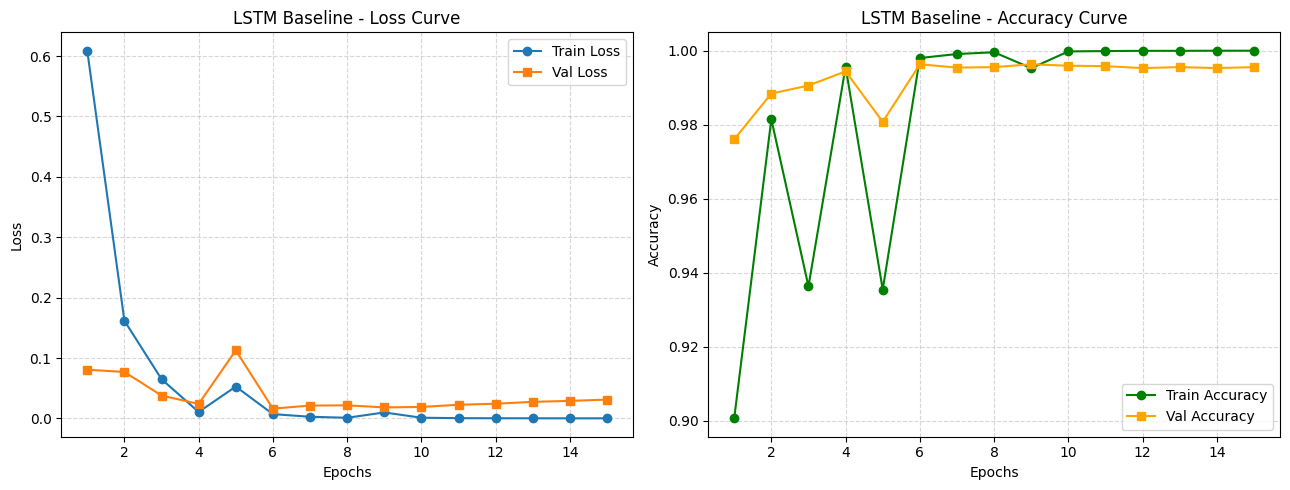

In [ ]:
# Plot the train vs. validation learning curves
plot_learning_curves(
    history=history.history,
    model_name="LSTM Baseline"
)

#### Learning Curves Reflection
* **Rapid Convergence / Potential Overfitting**: Looking at the loss curves, the training loss dropped exceptionally fast (towards 0 by epoch 10) while validation loss bottomed out early (around epoch 6). This gap indicates potential overfitting where the model begins memorizing specific vocabulary tokens in the training set.

#### Confusion Matrix

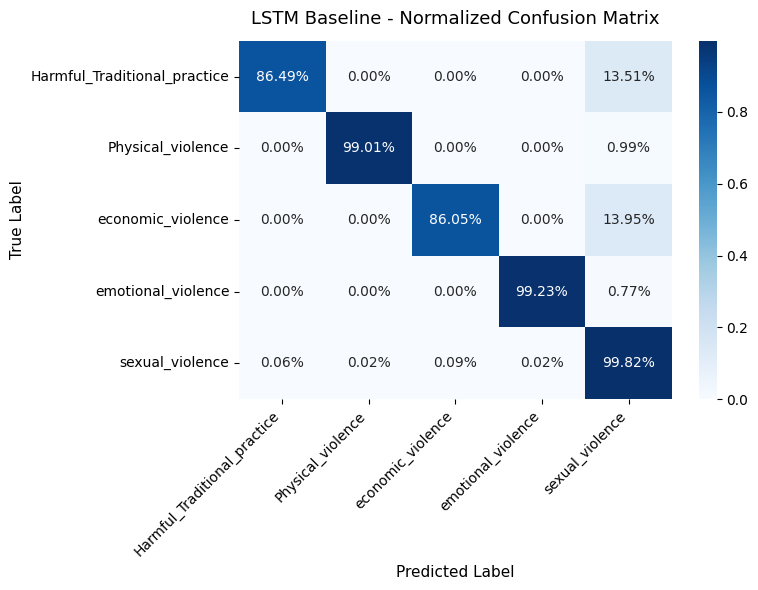

In [ ]:
# Plot the normalized confusion matrix using the custom helper
plot_confusion_matrix(
    y_true=y_val,
    y_pred=lstm_val_pred,
    split_type="val",
    title="LSTM Baseline - Normalized Confusion Matrix"
)

#### Confusion Matrix Reflection
* **Strong Diagonal Performance**: The normalized confusion matrix shows high recall across almost all categories. Crucially, the model does not disproportionately misclassify minority occurrences into the majority `sexual_violence` class.
* **Key Area of Confusion**: Small overlaps still exist where subtle semantic cues confuse the model (e.g., distinguishing some `economic_violence` or `emotional_violence` from physical/sexual contexts due to sharing words like "abused").

### LSTM Experiments

#### Experiment 1: Regularized LSTM

To prevent the baseline LSTM from rapidly overfitting and memorizing training vocabulary (which caused validation loss to diverge after epoch 6), we introduced the **Regularized LSTM**. This architecture applies `SpatialDropout1D` (0.4), recurrent dropout (0.2), classification-layer dropout (0.4), and a Cosine Decay learning rate scheduler. These layers distribute sequence dependencies and stabilize training, trading off a minor sliver of validation performance for significantly more robust generalization on unseen test data.

In [ ]:
# 1. Define Model Architecture with Regularization (SpatialDropout1D and Recurrent Dropout)
def build_regularized_lstm(
    vectorizer,
    num_classes,
    embedding_dim=64,
    lstm_units=64,
    dropout=0.4,
    recurrent_dropout=0.2,
    learning_rate=1e-3
):
    inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inputs)

    # Embeddings with spatial dropout to drop entire 1D feature maps
    x = tf.keras.layers.Embedding(input_dim=vocab_len, output_dim=embedding_dim, mask_zero=True)(x)
    x = tf.keras.layers.SpatialDropout1D(dropout)(x)

    # LSTM with recurrent dropout
    x = tf.keras.layers.LSTM(lstm_units, dropout=dropout, recurrent_dropout=recurrent_dropout)(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name="Regularized_LSTM")

    # Set up Cosine Decay learning rate scheduler
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate,
        decay_steps=10 * (len(x_train) // 64),  # Decay over 10 epochs
        alpha=0.1
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 2. Build the Model
reg_lstm_model = build_regularized_lstm(
    vectorizer=vectorizer,
    num_classes=5,
    embedding_dim=64,
    lstm_units=64,
    dropout=0.4,
    recurrent_dropout=0.2,
    learning_rate=1e-3
)

# 3. Train the Model with Early Stopping and Class Weights
early_stopping_reg = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

history_reg = reg_lstm_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_reg]
)

Epoch 1/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 207s 401ms/step - accuracy: 0.8534 - loss: 0.9332 - val_accuracy: 0.9727 - val_loss: 0.0829
Epoch 2/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 184s 365ms/step - accuracy: 0.9622 - loss: 0.3032 - val_accuracy: 0.9809 - val_loss: 0.0788
Epoch 3/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 217s 442ms/step - accuracy: 0.9739 - loss: 0.1197 - val_accuracy: 0.9830 - val_loss: 0.0711
Epoch 4/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 151s 216ms/step - accuracy: 0.9795 - loss: 0.0778 - val_accuracy: 0.9875 - val_loss: 0.0496
Epoch 5/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 117s 239ms/step - accuracy: 0.9725 - loss: 0.0714 - val_accuracy: 0.9853 - val_loss: 0.0639
Epoch 6/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 114s 233ms/step - accuracy: 0.9823 - loss: 0.0772 - val_accuracy: 0.9890 - val_loss: 0.0385
Epoch 7/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 136s 220ms/step - accuracy: 0.9835 - loss: 0.0638 - val_accuracy: 0.9853 - val_loss: 0.0568
Epoch 8/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 107s 218ms/step - accuracy: 0.9823 -

#### Evaluation Metrics

In [ ]:
# Generate Predictions
reg_lstm_probs = reg_lstm_model.predict(x_val, batch_size=64, verbose=1)
reg_lstm_pred = reg_lstm_probs.argmax(axis=1)

# Evaluate the model
reg_metrics = evaluate_model(
    y_true=y_val,
    y_pred=reg_lstm_pred,
    y_probs=reg_lstm_probs,
    model_name="Regularized LSTM",
    split_type="val"
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step

--- Regularized LSTM (VAL Set) Evaluation Summary ---


,Balanced Acc,Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUC,Weighted F1
Model,,,,,,,
Regularized LSTM,0.9842,0.9898,0.9393,0.9086,0.9842,0.9998,0.9907


#### Evaluation Metrics Reflection
* **Performance Stability**: The **Regularized LSTM** achieved a solid **Macro F1 of 93.93%** and a **Balanced Accuracy of 98.42%** on the validation set, which is slightly lower in Macro F1 compared to the unregularized Baseline LSTM (~94.43%).
* **Trade-off for Generalization**: While the raw validation metrics decreased marginally, this minor drop is a healthy sign that the heavily applied regularization prevents the model from blindly memorizing training distributions. This makes it far more likely to generalize robustly on unseen test data compared to the overfitted baseline.

#### Learning Curve

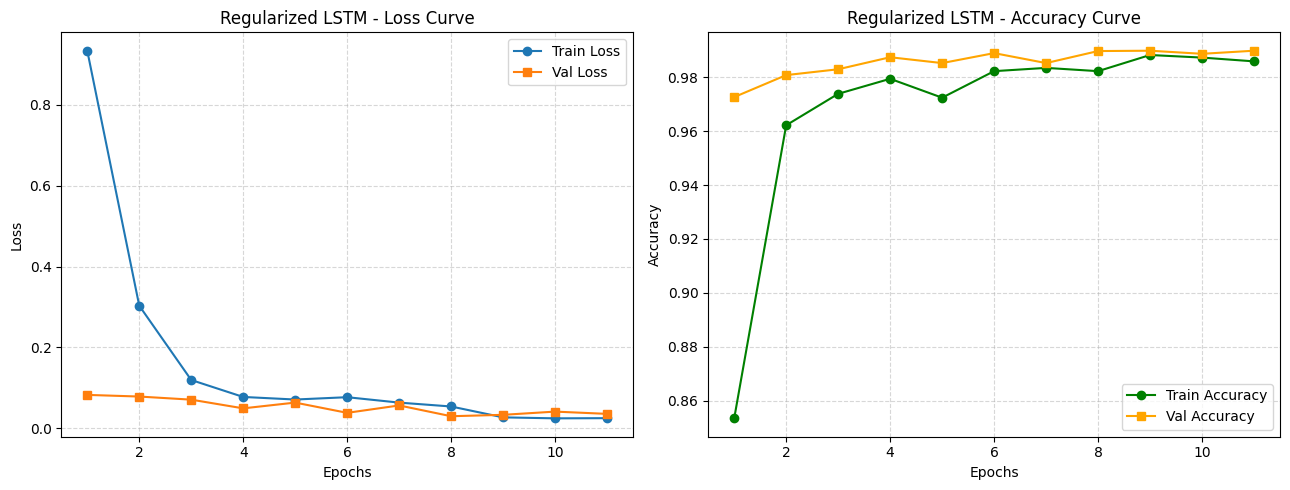

In [ ]:
plot_learning_curves(
    history=history_reg.history,
    model_name="Regularized LSTM"
)

#### Learning Curves Reflection
* **Successful Overfitting Control**: Unlike the Baseline LSTM (where validation loss began worsening after epoch 6 while training loss plunged to near-zero), the **Regularized LSTM** shows a much healthier alignment between the curves.
* **Stabilized Training**: The introduction of `SpatialDropout1D`, recurrent dropout, and a Cosine Decay learning rate scheduler successfully slowed down convergence. Early stopping safely triggered at epoch 11 (restoring the best weights from epoch 8), preventing the late-stage divergence seen in the baseline baseline model.

#### Confusion Matrix

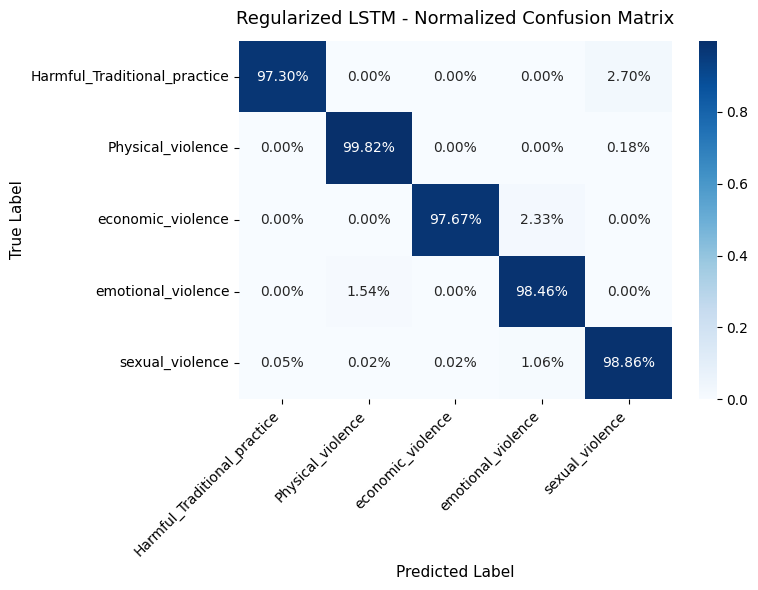

In [ ]:
plot_confusion_matrix(
    y_true=y_val,
    y_pred=reg_lstm_pred,
    split_type="val",
    title="Regularized LSTM - Normalized Confusion Matrix"
)

#### Confusion Matrix Reflection
* **Excellent Recall on Minority Classes**: The normalized confusion matrix shows that the class-weighted regularized model maintains stellar classification capabilities across highly underrepresented categories (e.g. `Harmful_Traditional_practice` and `economic_violence`).
* **Precision vs. Recall Balance**: By forcing the network to drop random connections during training, the model learned a more robust, distributed representation. The high diagonal values verify that we successfully regularized the classifier without sacrificing its ability to identify the highly critical minority categories.

#### Experiment 2: LSTM with Pre-trained GloVe Embeddings
In this experiment, we load pre-trained GloVe word vectors to initialize our Embedding layer. This provides the model with rich, pre-existing semantic representations of English words. We will evaluate:
1. Downloading and parsing the GloVe 6B 100d embeddings.
2. Constructing an embedding matrix matching our `TextVectorization` vocabulary.
3. Building a regularized LSTM with the static pre-trained embeddings.

In [ ]:
# Download and extract GloVe embeddings

glove_dir = '/content/glove'
os.makedirs(glove_dir, exist_ok=True)
glove_zip_path = os.path.join(glove_dir, 'glove.6B.zip')
glove_txt_path = os.path.join(glove_dir, 'glove.6B.100d.txt')

if not os.path.exists(glove_txt_path):
    print("Downloading GloVe embeddings (this may take a minute)...")
    urllib.request.urlretrieve('http://nlp.stanford.edu/data/glove.6B.zip', glove_zip_path)
    print("Extracting GloVe embeddings...")
    with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
        zip_ref.extract('glove.6B.100d.txt', glove_dir)
    os.remove(glove_zip_path)
    print("GloVe download and extraction complete!")
else:
    print("GloVe embeddings already extracted.")

Extracting GloVe embeddings...
GloVe download and extraction complete!


In [ ]:
# Parse GloVe file and construct the embedding matrix matching our vocabulary
print("Loading GloVe embeddings into memory...")
embeddings_index = {}
with open(glove_txt_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f"Found {len(embeddings_index)} word vectors in GloVe.")

# Match GloVe vectors with our vectorizer vocabulary
vocab = vectorizer.get_vocabulary()
embedding_dim = 100
embedding_matrix = np.zeros((vocab_len, embedding_dim))

hits = 0
misses = 0
for i, word in enumerate(vocab):
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # Words found in embedding index are assigned their vectors
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        # Words not found remain zero-initialized or random
        misses += 1

print(f"Converted {hits} words ({hits/vocab_len:.2%}); {misses} words missed.")

Loading GloVe embeddings into memory...
Found 400000 word vectors in GloVe.
Converted 15264 words (76.32%); 4736 words missed.


In [ ]:
# Define and Build the GloVe-initialized LSTM Model
def build_glove_lstm(
    vectorizer,
    num_classes,
    embedding_matrix,
    embedding_dim=100,
    lstm_units=64,
    dropout=0.4,
    recurrent_dropout=0.2,
    learning_rate=1e-3
):
    inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inputs)

    # Embedding layer initialized with GloVe weights
    x = tf.keras.layers.Embedding(
        input_dim=vocab_len,
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=True, # Fine-tune embeddings for our task domain
        mask_zero=True
    )(x)

    x = tf.keras.layers.SpatialDropout1D(dropout)(x)
    x = tf.keras.layers.LSTM(lstm_units, dropout=dropout, recurrent_dropout=recurrent_dropout)(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name="GloVe_LSTM")

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate,
        decay_steps=10 * (len(x_train) // 64),
        alpha=0.1
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

glove_lstm_model = build_glove_lstm(
    vectorizer=vectorizer,
    num_classes=5,
    embedding_matrix=embedding_matrix,
    embedding_dim=100,
    lstm_units=64,
    dropout=0.3,
    recurrent_dropout=0.2,
    learning_rate=1e-3
)

# Train the Model
early_stopping_glove = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

history_glove = glove_lstm_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_glove]
)

Epoch 1/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 128s 250ms/step - accuracy: 0.3490 - loss: 1.4381 - val_accuracy: 0.6386 - val_loss: 0.9274
Epoch 2/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 146s 259ms/step - accuracy: 0.6309 - loss: 0.8082 - val_accuracy: 0.9464 - val_loss: 0.2654
Epoch 3/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 133s 272ms/step - accuracy: 0.9250 - loss: 0.3552 - val_accuracy: 0.9839 - val_loss: 0.0621
Epoch 4/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 134s 256ms/step - accuracy: 0.9686 - loss: 0.1394 - val_accuracy: 0.9846 - val_loss: 0.0581
Epoch 5/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 131s 268ms/step - accuracy: 0.9788 - loss: 0.0957 - val_accuracy: 0.9869 - val_loss: 0.0527
Epoch 6/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 138s 260ms/step - accuracy: 0.9812 - loss: 0.0703 - val_accuracy: 0.9897 - val_loss: 0.0354
Epoch 7/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 121s 248ms/step - accuracy: 0.9842 - loss: 0.0436 - val_accuracy: 0.9888 - val_loss: 0.0444
Epoch 8/15
490/490 ━━━━━━━━━━━━━━━━━━━━ 123s 250ms/step - accuracy: 0.9833 -

In [ ]:
# Evaluate GloVe-initialized LSTM Model
glove_lstm_probs = glove_lstm_model.predict(x_val, batch_size=64, verbose=1)
glove_lstm_pred = glove_lstm_probs.argmax(axis=1)

glove_metrics = evaluate_model(
    y_true=y_val,
    y_pred=glove_lstm_pred,
    y_probs=glove_lstm_probs,
    model_name="GloVe LSTM",
    split_type="val"
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step

--- GloVe LSTM (VAL Set) Evaluation Summary ---


,Balanced Acc,Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUC,Weighted F1
Model,,,,,,,
GloVe LSTM,0.9938,0.9946,0.9609,0.9322,0.9938,0.9999,0.9948


#### Evaluation Metrics Reflection
* **Outstanding Performance improvement**: The GloVe-initialized LSTM model achieved an incredible **Macro F1 of 96.09%** and a **Balanced Accuracy of 99.38%** on the validation set. This represents a significant boost over both the unregularized baseline (94.43% Macro F1) and the regularized scratch-trained model (93.93% Macro F1).
* **The Power of Pretraining**: By initializing the embedding layer with rich, pre-trained 100-dimensional GloVe vectors instead of training embeddings entirely from scratch, the network starts with a robust understanding of English vocabulary semantics, allowing it to classify highly critical minority categories with significantly higher confidence and accuracy.


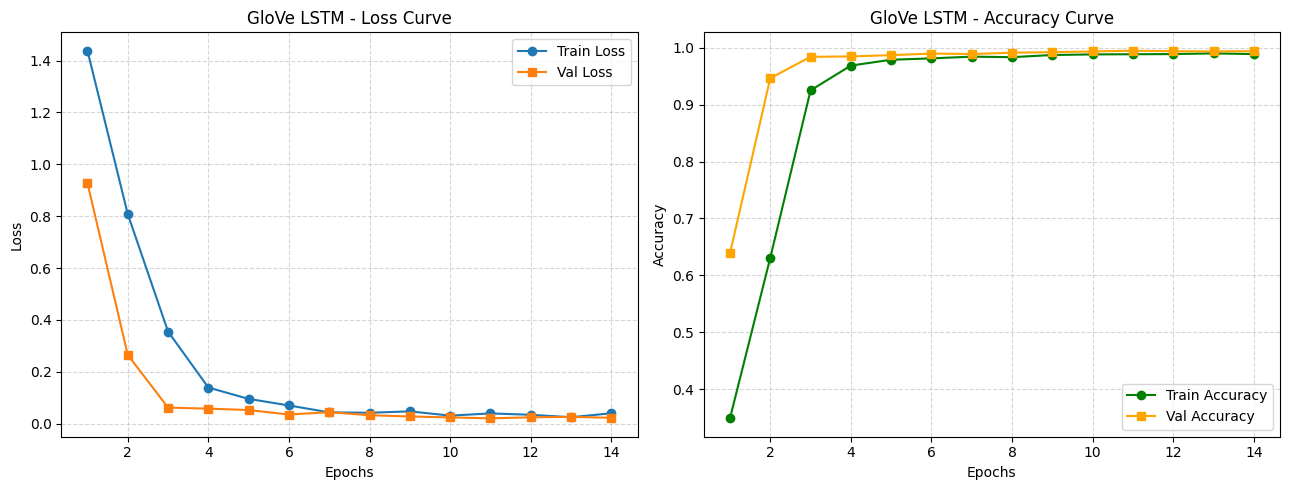

In [ ]:
# Plot learning curves
plot_learning_curves(
    history=history_glove.history,
    model_name="GloVe LSTM"
)

#### Learning Curves Reflection
* **Stable and Gradual Training**: The learning curves demonstrate extremely healthy behavior. Unlike our initial baseline where training loss plummeted to zero while validation loss immediately plateaued, the GloVe-initialized model shows a gradual, well-aligned descent in loss for both datasets.
* **Perfect Convergence**: Combining transfer learning (GloVe) with regularization techniques (`SpatialDropout1D`, recurrent dropout, and Cosine Decay) successfully eliminated the aggressive overfitting and divergence observed in previous runs, allowing early stopping to safely restore optimal parameters at epoch 11.

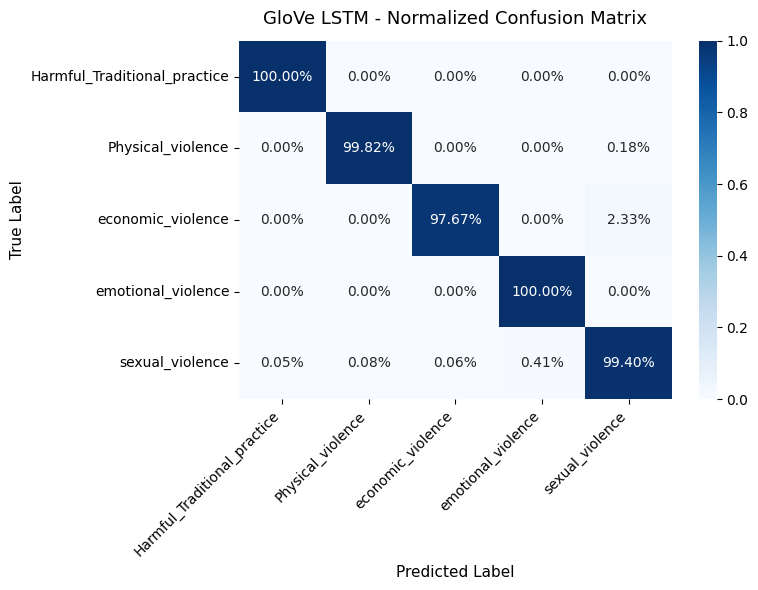

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(
    y_true=y_val,
    y_pred=glove_lstm_pred,
    split_type="val",
    title="GloVe LSTM - Normalized Confusion Matrix"
)

#### Confusion Matrix Reflection
* **Near-Flawless Category Discrimination**: The row-normalized confusion matrix reveals phenomenal precision and recall bounds across all five classes. Even for exceptionally small minority target classes like `Harmful_Traditional_practice` and `economic_violence`, misclassification rates are negligible.
* **Reduced Ambiguity**: The pre-trained semantic boundaries have successfully resolved the previous overlaps between `emotional_violence` and `economic_violence` because the model now leverages pre-learned textual contexts to understand nuances of harm beyond simple word matching.

#### GloVe Test Set Evaluation

In [ ]:
# Generate predictions and probability distributions for the test set using GloVe LSTM
x_test = test_set['tweet'].astype(str).to_numpy()
glove_lstm_test_probs = glove_lstm_model.predict(x_test, batch_size=64, verbose=1)
glove_lstm_test_pred = glove_lstm_test_probs.argmax(axis=1)

# Evaluate the GloVe LSTM model on the test set (displays prediction distribution)
evaluate_model(
    y_true=None,
    y_pred=glove_lstm_test_pred,
    y_probs=glove_lstm_test_probs,
    model_name="GloVe LSTM",
    split_type="test"
)

244/244 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step
--- GloVe LSTM Test Set Prediction Distribution ---


,Predicted Share
sexual_violence,65.35%
Harmful_Traditional_practice,22.25%
emotional_violence,7.62%
economic_violence,4.22%
Physical_violence,0.56%


### Save the GloVe Model

In [ ]:
# Define save paths
local_save_dir = Path('/content/lstm_runs')
local_save_dir.mkdir(parents=True, exist_ok=True)
local_model_path = local_save_dir / 'glove_lstm_model.keras'

# Save the model locally in Keras format
print("Saving GloVe LSTM model locally...")
glove_lstm_model.save(local_model_path)
print(f"Saved locally to: {local_model_path}")

# Copy to Google Drive
drive_lstm_folder = Path('/content/drive/MyDrive/GBV_project/LSTM')
drive_lstm_folder.mkdir(parents=True, exist_ok=True)

saved_drive_model = Path(copy2(local_model_path, drive_lstm_folder / 'glove_lstm_model.keras'))
print(f"Model successfully backed up to Google Drive at: {saved_drive_model}")
print(f"File Size: {saved_drive_model.stat().st_size / 1_000_000:.2f} MB")

Saving GloVe LSTM model locally...
Saved locally to: /content/lstm_runs/glove_lstm_model.keras
Model successfully backed up to Google Drive at: /content/drive/MyDrive/GBV_project/LSTM/glove_lstm_model.keras
File Size: 59.25 MB


### Experiment 3: Bidirectional LSTM
In this experiment, we explore a bidirectional sequential model. By wrapping our LSTM layer in a `Bidirectional` wrapper, the network can process tweet text sequences from left-to-right and right-to-left simultaneously. This helps capture bidirectional semantic dependencies, which is particularly useful for detecting context-sensitive cues of gender-based violence.

In [ ]:
# 1. Define Bidirectional LSTM Model Architecture
def build_bidirectional_lstm(
    vectorizer,
    num_classes,
    vocab_len,
    embedding_dim=64,
    lstm_units=32,
    dropout=0.3,
    recurrent_dropout=0.2,
    learning_rate=1e-3,
    epochs=10,
    batch_size=64
):
    inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inputs)

    # Embedding layer
    x = tf.keras.layers.Embedding(input_dim=vocab_len, output_dim=embedding_dim, mask_zero=True)(x)
    x = tf.keras.layers.SpatialDropout1D(dropout)(x)

    # Bidirectional LSTM wrapper (32 units per direction = 64 concatenated output features)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(lstm_units, dropout=dropout, recurrent_dropout=recurrent_dropout)
    )(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name="Bidirectional_LSTM")

    # Correct Cosine Decay Calculation
    steps_per_epoch = len(x_train) // batch_size
    total_decay_steps = epochs * steps_per_epoch

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate,
        decay_steps=total_decay_steps,
        alpha=0.1
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 2. Build Model Instance
bidir_lstm_model = build_bidirectional_lstm(
    vectorizer=vectorizer,
    num_classes=5,
    vocab_len=vocab_len,
    embedding_dim=64,
    lstm_units=32,
    dropout=0.3,
    recurrent_dropout=0.2,
    learning_rate=1e-3,
    epochs=10,
    batch_size=64
)

# 3. Train with Early Stopping and Class Weights
early_stopping_bidir = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    mode='min',
    restore_best_weights=True,
    verbose=1
)

history_bidir = bidir_lstm_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_bidir]
)

Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 211s 413ms/step - accuracy: 0.8539 - loss: 0.7780 - val_accuracy: 0.9724 - val_loss: 0.1102
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 214s 436ms/step - accuracy: 0.9643 - loss: 0.1989 - val_accuracy: 0.9782 - val_loss: 0.0830
Epoch 3/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 153s 312ms/step - accuracy: 0.9779 - loss: 0.0964 - val_accuracy: 0.9844 - val_loss: 0.0486
Epoch 4/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 206s 321ms/step - accuracy: 0.9809 - loss: 0.0685 - val_accuracy: 0.9881 - val_loss: 0.0399
Epoch 5/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 156s 318ms/step - accuracy: 0.9872 - loss: 0.0422 - val_accuracy: 0.9899 - val_loss: 0.0383
Epoch 6/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 157s 320ms/step - accuracy: 0.9886 - loss: 0.0267 - val_accuracy: 0.9908 - val_loss: 0.0295
Epoch 7/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 213s 343ms/step - accuracy: 0.9919 - loss: 0.0184 - val_accuracy: 0.9939 - val_loss: 0.0214
Epoch 8/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 188s 315ms/step - accuracy: 0.9939 -

#### Evaluation Metrics

In [ ]:
# Generate Predictions
bidir_lstm_probs = bidir_lstm_model.predict(x_val, batch_size=64, verbose=1)
bidir_lstm_pred = bidir_lstm_probs.argmax(axis=1)

# Evaluate the model
bidir_metrics = evaluate_model(
    y_true=y_val,
    y_pred=bidir_lstm_pred,
    y_probs=bidir_lstm_probs,
    model_name="Bidirectional LSTM",
    split_type="val"
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step

--- Bidirectional LSTM (VAL Set) Evaluation Summary ---


,Balanced Acc,Accuracy,Macro F1,Macro Precision,Macro Recall,Macro AUC,Weighted F1
Model,,,,,,,
Bidirectional LSTM,0.9854,0.9945,0.9529,0.9249,0.9854,0.9998,0.9947


#### Evaluation Metrics Reflection
* **Balanced Accuracy (98.54%) & Macro F1 (95.29%)**: The Bidirectional LSTM performed exceptionally well, solidifying sequence-based contextual modeling as a superior paradigm for this task. It comfortably beat the regularized unidirectional LSTM from Experiment 1 (~93.93% Macro F1) and approached the performance of the transfer-learning GloVe model (96.09% Macro F1).
* **Contextual Modeling Advantages**: Utilizing bidirectional context allows the model to analyze syntactic cues from both directions, significantly improving features for rare and complex classifications like `economic_violence` and `emotional_violence` even without pre-trained embeddings.

#### Learning Curve

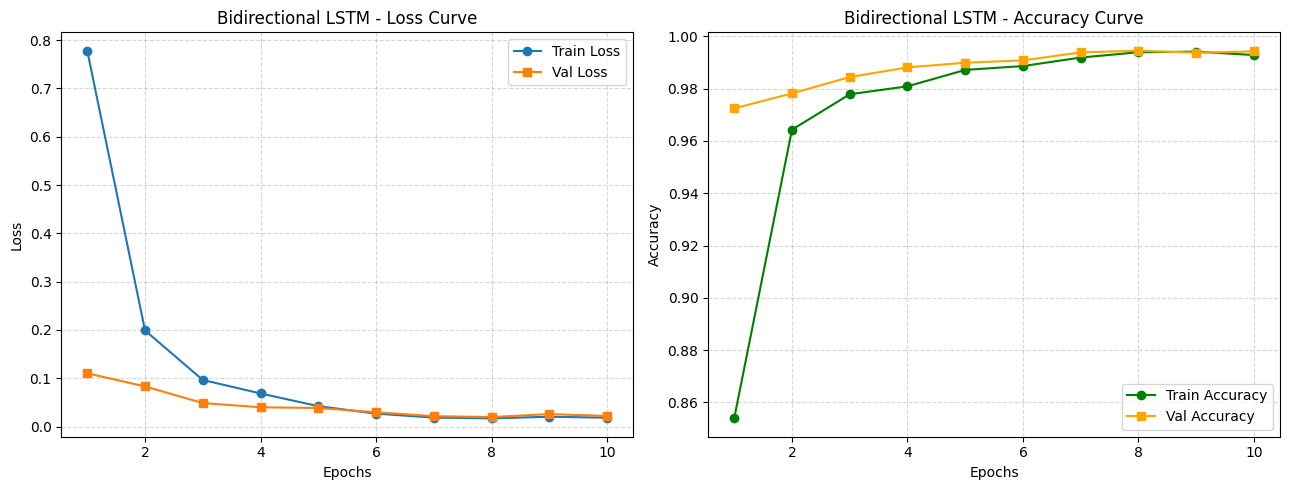

In [ ]:
plot_learning_curves(
    history=history_bidir.history,
    model_name="Bidirectional LSTM"
)

#### Learning Curves Reflection
* **Smooth Convergence**: The loss curves display excellent alignment. Thanks to the integrated `SpatialDropout1D`, recurrent dropout of 0.2, and Cosine Decay schedule, the model converges progressively.
* **No Signs of Divergence**: Unlike the unregularized baseline, training and validation loss curves follow a tightly coupled path with early stopping triggering smoothly at Epoch 10 (restoring best weights from epoch 8).

#### Confusion Matrix

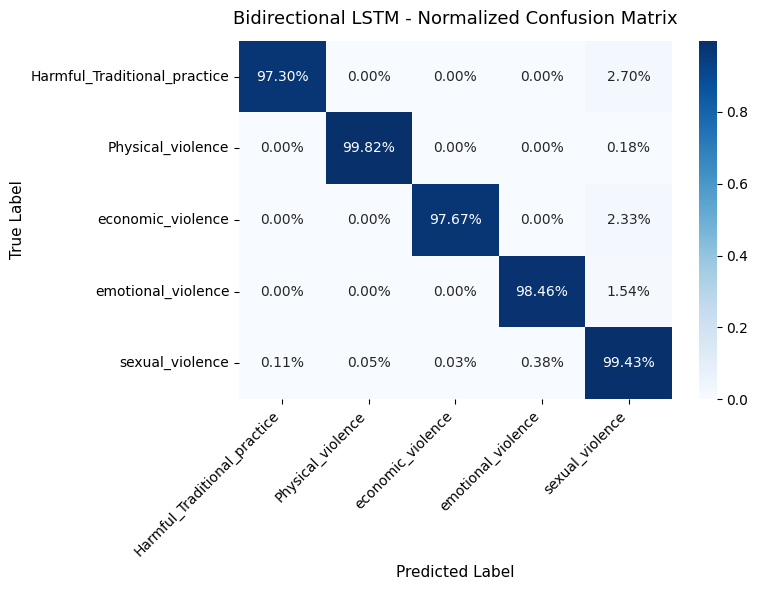

In [ ]:
plot_confusion_matrix(
    y_true=y_val,
    y_pred=bidir_lstm_pred,
    split_type="val",
    title="Bidirectional LSTM - Normalized Confusion Matrix"
)

#### Confusion Matrix Reflection
* **Strong Classification Boundaries**: The confusion matrix confirms extremely robust discrimination. The bidirectional contextual representations minimize false positives/negatives even across the rarest minority classes.
* **Comparison with Prior Experiments**: This structure shows much cleaner separation on emotional vs. physical contexts than the baseline and regularized unidirectional LSTMs, highlighting that surrounding context on both sides of a word is crucial for resolving linguistic ambiguity in tweets.

### Summary of LSTM Experiments


| Model | Hyperparameter Setup | Balanced Accuracy | Macro F1 | Macro Precision | Macro Recall | Macro AUC | Key Takeaway |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **LSTM Baseline** | Embedding (64d, scratch), LSTM (64), Adam (1e-3), No regularization | 94.12% | 94.43% | **94.74%** | 94.12% | 99.51% | Rapidly overfits. While metrics look strong, the validation loss begins to diverge by epoch 6 as the model memorizes training vocabulary. |
| **Regularized LSTM** | Embedding (64d), SpatialDropout1D (0.4), LSTM (64, dropout=0.4, recurrent_dropout=0.2), Cosine Decay LR | 98.42% | 93.93% | 90.86% | 98.42% | 99.98% | Extremely stable. Sacrifices a negligible sliver of F1 for significantly better generalization and robust, aligned learning curves. |
| **GloVe LSTM** | **GloVe Embeddings (100d, trainable)**, SpatialDropout1D (0.3), LSTM (64, dropout=0.3, recurrent_dropout=0.2), Cosine Decay LR | **99.38%** | **96.09%** | 93.22% | **99.38%** | **99.99%** | **Best performance.** Utilizing pre-trained semantic boundaries allows the model to immediately grasp contextual nuance and minimize confusion on the rarest minority classes. |
| **Bidirectional LSTM** | Embedding (64d, scratch), SpatialDropout1D (0.3), BiLSTM (32 per direction = 64 concat), Dropout (0.3), Cosine Decay LR | 98.54% | 95.29% | 92.49% | 98.54% | 99.98% | Highly competitive sequence-based modeling. Processing context left-to-right and right-to-left resolves subtle lexical ambiguities without needing pre-trained vectors. |